# EXP3-D · Naive Bayes

Trains **Gaussian Naive Bayes** with 2-stage optimization across 6 sampling methods.  
Uses calibrated probabilities and the same sampling pipeline as other EXP3 notebooks.  
Run in parallel with EXP3-A, EXP3-B, and EXP3-C.

In [3]:
# Optional install (uncomment if needed), then restart kernel once.
%pip install -q numpy pandas scipy scikit-learn xgboost catboost joblib venn-abers seaborn matplotlib imbalanced-learn torch shap lime naive-bayes
%pip install -q cuml-cu13 --extra-index-url=https://pypi.nvidia.com

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [5]:
import json
import random
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform, loguniform

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss
from sklearn.model_selection import ParameterSampler, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 300)

xgb_available = True
cat_available = True
venn_available = True
torch_available = True
torch_cuda_available = False
cuml_available = True

try:
    from xgboost import XGBClassifier
except Exception:
    xgb_available = False
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except Exception:
    cat_available = False
    CatBoostClassifier = None

try:
    from venn_abers import VennAbers
except Exception:
    venn_available = False
    VennAbers = None

try:
    import torch
    torch_cuda_available = bool(torch.cuda.is_available())
except Exception:
    torch_available = False

try:
    from cuml.ensemble import RandomForestClassifier as cuRFClassifier
except Exception:
    cuml_available = False
    cuRFClassifier = None

print({
    'xgboost': xgb_available,
    'catboost': cat_available,
    'venn_abers': venn_available,
    'torch': torch_available,
    'torch_cuda': torch_cuda_available,
    'cuml_rf': cuml_available,
})

{'xgboost': True, 'catboost': True, 'venn_abers': True, 'torch': True, 'torch_cuda': True, 'cuml_rf': False}


In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Resolve project root so notebook runs from FINAL or its parent folder.
CWD = Path.cwd()
if (CWD / 'Datasets2015').exists():
    PROJECT_ROOT = CWD
elif (CWD / 'FINAL' / 'Datasets2015').exists():
    PROJECT_ROOT = CWD / 'FINAL'
elif (CWD.parent / 'Datasets2015').exists():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = CWD

PARENT_ROOT = PROJECT_ROOT.parent

def _unique_paths(paths):
    out, seen = [], set()
    for p in paths:
        if p not in seen:
            seen.add(p)
            out.append(p)
    return out

DATASET2015_CANDIDATES = _unique_paths([
    PROJECT_ROOT / 'Datasets2015',
    PARENT_ROOT / 'Datasets2015',
    PROJECT_ROOT / 'FINAL' / 'Datasets2015',
    PARENT_ROOT / 'FINAL' / 'Datasets2015',
])

AUTO_MERGED_DATA_PATH = None
DATA_CANDIDATES = _unique_paths([
    PROJECT_ROOT / 'merged_clinical_dietary_anthro_leftjoin.csv',
    PROJECT_ROOT / 'merged_clinical_dietary_leftjoin.csv',
    PROJECT_ROOT / 'merged_clinical_leftjoin.csv',
    PARENT_ROOT / 'merged_clinical_dietary_anthro_leftjoin.csv',
    PARENT_ROOT / 'merged_clinical_dietary_leftjoin.csv',
    PARENT_ROOT / 'merged_clinical_leftjoin.csv',
    PROJECT_ROOT / 'FINAL' / 'merged_clinical_dietary_anthro_leftjoin.csv',
    PROJECT_ROOT / 'FINAL' / 'merged_clinical_dietary_leftjoin.csv',
    PROJECT_ROOT / 'FINAL' / 'merged_clinical_leftjoin.csv',
    PARENT_ROOT / 'FINAL' / 'merged_clinical_dietary_anthro_leftjoin.csv',
    PARENT_ROOT / 'FINAL' / 'merged_clinical_dietary_leftjoin.csv',
    PARENT_ROOT / 'FINAL' / 'merged_clinical_leftjoin.csv',
])

TARGET_CANDIDATES = ['hypertension', 'htn', 'target', 'label', 'outcome']
COLLINEARITY_CUTOFF = 0.70

STAGE1_EPOCHS = 120
STAGE2_EPOCHS = 300
FINAL_EPOCHS = 900

STAGE1_TRIALS_PER_MODEL = 180
STAGE2_REFINEMENTS_PER_TOP_CONFIG = 24
TOP_K_STAGE1 = 8
TOP_K_STAGE2 = 3
CV_FOLDS_STAGE1 = 5
CV_FOLDS_STAGE2 = 6

USE_GPU_WHEN_AVAILABLE = True
N_JOBS = -1

print('Project root:', PROJECT_ROOT)

Artifacts: /workspace/Thesis-part-2/gpuV2.2.1.1/Main_2015_GPU_RF_XGB_CAT_RIGOROUS_OPT_exp2.ipynb_rf_xgb_cat_exp2_artifacts


In [ ]:
def _normalize_join_columns(df_in):
    rename_map = {}
    col_lc = {c.lower(): c for c in df_in.columns}
    for key in ['hhnum', 'member_code']:
        if key in col_lc and col_lc[key] != key:
            rename_map[col_lc[key]] = key
    return df_in.rename(columns=rename_map)

def _find_anthropometric_dataset_path():
    for base in DATASET2015_CANDIDATES:
        anthro_dir = base / 'Anthropometric'
        if not anthro_dir.exists():
            continue

        csv_paths = sorted([p for p in anthro_dir.glob('*.csv') if 'dictionary' not in p.name.lower()])
        preferred = [
            p for p in csv_paths
            if ('data-set' in p.name.lower()) or ('dataset' in p.name.lower())
        ]
        for p in preferred + csv_paths:
            return p
    return None

def _prepare_merged_with_anthro(base_path):
    if not base_path.exists():
        return None

    try:
        base_df = pd.read_csv(base_path)
    except Exception:
        return None

    anthro_tokens = ['weight', 'height', 'waist', 'hip', 'bmi', 'whr']
    has_anthro = any(any(tok in c.lower() for tok in anthro_tokens) for c in base_df.columns)
    if has_anthro:
        return base_path

    anthro_path = _find_anthropometric_dataset_path()
    if anthro_path is None:
        return None

    try:
        anthro_df = pd.read_csv(anthro_path)
    except Exception:
        return None

    base_df = _normalize_join_columns(base_df)
    anthro_df = _normalize_join_columns(anthro_df)

    join_keys = [k for k in ['hhnum', 'member_code'] if k in base_df.columns and k in anthro_df.columns]
    if not join_keys:
        return None

    anthro_df = anthro_df.drop_duplicates(subset=join_keys, keep='first')

    overlap = [c for c in anthro_df.columns if c in base_df.columns and c not in join_keys]
    if overlap:
        anthro_df = anthro_df.rename(columns={c: f'{c}_anthro' for c in overlap})

    merged_df = base_df.merge(anthro_df, on=join_keys, how='left')
    out_path = PROJECT_ROOT / 'merged_clinical_dietary_anthro_leftjoin.csv'
    merged_df.to_csv(out_path, index=False)

    print(f'Prepared anthropometric-augmented dataset: {out_path}')
    print(f'  source merged file: {base_path}')
    print(f'  source anthropometric file: {anthro_path}')
    print(f'  join keys: {join_keys}')
    return out_path

def resolve_data_path(candidates):
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f'No dataset found. Checked: {candidates}')

def infer_target_column(df, candidates):
    lc = {c.lower(): c for c in df.columns}
    for t in candidates:
        if t.lower() in lc:
            return lc[t.lower()]
    for c in df.columns:
        c_lc = c.lower()
        if any(t.lower() in c_lc for t in candidates):
            return c
    return None

def infer_bp_columns(df):
    sbp_aliases = ['ave_sbp']
    dbp_aliases = ['ave_dbp']

    lc = {c.lower(): c for c in df.columns}

    sbp_col = None
    for a in sbp_aliases:
        if a in lc:
            sbp_col = lc[a]
            break
    if sbp_col is None:
        for c in df.columns:
            c_lc = c.lower()
            if any(a in c_lc for a in sbp_aliases):
                sbp_col = c
                break

    dbp_col = None
    for a in dbp_aliases:
        if a in lc:
            dbp_col = lc[a]
            break
    if dbp_col is None:
        for c in df.columns:
            c_lc = c.lower()
            if any(a in c_lc for a in dbp_aliases):
                dbp_col = c
                break

    return sbp_col, dbp_col

def find_first_column_case_insensitive(columns, candidates):
    lc = {c.lower(): c for c in columns}
    for cand in candidates:
        cand_lc = cand.lower()
        if cand_lc in lc:
            return lc[cand_lc]
    for c in columns:
        c_lc = c.lower()
        if any(cand.lower() in c_lc for cand in candidates):
            return c
    return None

def to_numeric_clean(series):
    s = pd.to_numeric(series, errors='coerce')
    return s.where(~s.isin([9, 99, 888888, 999999]), np.nan)

def build_smoking_level_feature(df_in):
    used_cols = []
    smoking_level_col = find_first_column_case_insensitive(df_in.columns, ['smoking_level'])
    smoke_status_col = find_first_column_case_insensitive(df_in.columns, ['smoke_status'])
    current_smoking_col = find_first_column_case_insensitive(df_in.columns, ['current_smoking', 'currentsmoking'])
    ever_smoke_col = find_first_column_case_insensitive(df_in.columns, ['ever_smk'])

    if smoking_level_col is not None:
        s = to_numeric_clean(df_in[smoking_level_col]).clip(lower=0, upper=3)
        used_cols.append(smoking_level_col)
        return s.astype(float), sorted(set(used_cols))

    idx = df_in.index
    smoke = pd.Series(np.nan, index=idx, dtype=float)

    if smoke_status_col is not None:
        status = to_numeric_clean(df_in[smoke_status_col])
        used_cols.append(smoke_status_col)
        smoke.loc[status == 0] = 0
        smoke.loc[status == 2] = 1
        smoke.loc[status == 1] = 2
        if current_smoking_col is not None:
            current = to_numeric_clean(df_in[current_smoking_col])
            used_cols.append(current_smoking_col)
            smoke.loc[(status == 1) & (current == 3)] = 3
        return smoke.astype(float), sorted(set(used_cols))

    if current_smoking_col is not None:
        current = to_numeric_clean(df_in[current_smoking_col])
        used_cols.append(current_smoking_col)
        smoke.loc[current == 0] = 0
        smoke.loc[current.isin([1, 2])] = 2
        smoke.loc[current == 3] = 3
        if ever_smoke_col is not None:
            ever = to_numeric_clean(df_in[ever_smoke_col])
            used_cols.append(ever_smoke_col)
            smoke.loc[(current == 0) & (ever > 0)] = 1
        return smoke.astype(float), sorted(set(used_cols))

    if ever_smoke_col is not None:
        ever = to_numeric_clean(df_in[ever_smoke_col])
        used_cols.append(ever_smoke_col)
        smoke.loc[ever == 0] = 0
        smoke.loc[ever > 0] = 1
        return smoke.astype(float), sorted(set(used_cols))

    return None, []

def build_alcohol_level_feature(df_in):
    used_cols = []
    alcohol_level_col = find_first_column_case_insensitive(df_in.columns, ['alcohol_level'])
    alcohol_status_col = find_first_column_case_insensitive(df_in.columns, ['alcohol_status'])
    alcohol_ever_col = find_first_column_case_insensitive(df_in.columns, ['alcohol'])
    current_alcohol_col = find_first_column_case_insensitive(df_in.columns, ['con_alcohol'])
    drink30_col = find_first_column_case_insensitive(df_in.columns, ['drnk_30days'])
    binge_col = find_first_column_case_insensitive(df_in.columns, ['binge_drink', 'binge_drinking'])

    if alcohol_level_col is not None:
        a = to_numeric_clean(df_in[alcohol_level_col]).clip(lower=0, upper=3)
        used_cols.append(alcohol_level_col)
        return a.astype(float), sorted(set(used_cols))

    idx = df_in.index
    alcohol = pd.Series(np.nan, index=idx, dtype=float)

    if alcohol_status_col is not None:
        status = to_numeric_clean(df_in[alcohol_status_col])
        used_cols.append(alcohol_status_col)
        alcohol.loc[status == 0] = 0
        alcohol.loc[status == 2] = 1
        alcohol.loc[status == 1] = 2
        if binge_col is not None:
            binge = to_numeric_clean(df_in[binge_col])
            used_cols.append(binge_col)
            alcohol.loc[(status == 1) & (binge == 1)] = 3
        return alcohol.astype(float), sorted(set(used_cols))

    alcohol.loc[:] = 0
    if alcohol_ever_col is not None:
        ever = to_numeric_clean(df_in[alcohol_ever_col])
        used_cols.append(alcohol_ever_col)
        alcohol.loc[ever > 0] = 1
    if current_alcohol_col is not None:
        current = to_numeric_clean(df_in[current_alcohol_col])
        used_cols.append(current_alcohol_col)
        alcohol.loc[current == 1] = np.maximum(alcohol.loc[current == 1], 2)
    if drink30_col is not None:
        d30 = to_numeric_clean(df_in[drink30_col])
        used_cols.append(drink30_col)
        alcohol.loc[d30 == 1] = np.maximum(alcohol.loc[d30 == 1], 2)
    if binge_col is not None:
        binge = to_numeric_clean(df_in[binge_col])
        used_cols.append(binge_col)
        alcohol.loc[binge == 1] = 3

    if used_cols:
        return alcohol.astype(float), sorted(set(used_cols))

    return None, []

def build_bmi_feature(df_in):
    weight_col = find_first_column_case_insensitive(df_in.columns, ['weight'])
    height_col = find_first_column_case_insensitive(df_in.columns, ['height'])
    if weight_col is None or height_col is None:
        return None, []
    w = pd.to_numeric(df_in[weight_col], errors='coerce')
    h = pd.to_numeric(df_in[height_col], errors='coerce')
    h_m = h.copy()
    if pd.notna(h_m.median(skipna=True)) and float(h_m.median(skipna=True)) > 3.0:
        h_m = h_m / 100.0
    bmi = w / (h_m ** 2)
    bmi = bmi.replace([np.inf, -np.inf], np.nan)
    return bmi.astype(float), [weight_col, height_col]

def build_whr_feature(df_in):
    waist_col = find_first_column_case_insensitive(df_in.columns, ['waist'])
    hip_col = find_first_column_case_insensitive(df_in.columns, ['hip'])
    if waist_col is None or hip_col is None:
        return None, []
    waist = pd.to_numeric(df_in[waist_col], errors='coerce')
    hip = pd.to_numeric(df_in[hip_col], errors='coerce').replace(0, np.nan)
    whr = (waist / hip).replace([np.inf, -np.inf], np.nan)
    return whr.astype(float), [waist_col, hip_col]

In [8]:
AUTO_MERGED_DATA_PATH = None
for merged_candidate in [
    PROJECT_ROOT / 'merged_clinical_dietary_leftjoin.csv',
    PROJECT_ROOT.parent / 'merged_clinical_dietary_leftjoin.csv',
]:
    AUTO_MERGED_DATA_PATH = _prepare_merged_with_anthro(merged_candidate)
    if AUTO_MERGED_DATA_PATH is not None:
        break

effective_candidates = [
    AUTO_MERGED_DATA_PATH,
    *DATA_CANDIDATES,
]
effective_candidates = [p for p in effective_candidates if p is not None]

data_path = resolve_data_path(effective_candidates)
df = pd.read_csv(data_path)
target_col = infer_target_column(df, TARGET_CANDIDATES)
TARGET_DEFINED_FROM_BP = False
TARGET_SOURCE_COLUMNS = []

if target_col is None:
    sbp_col, dbp_col = infer_bp_columns(df)
    if sbp_col is not None and dbp_col is not None:
        sbp = pd.to_numeric(df[sbp_col], errors='coerce')
        dbp = pd.to_numeric(df[dbp_col], errors='coerce')
        df['Hypertension'] = (((sbp >= 140) | (dbp >= 90)).fillna(False)).astype(int)
        target_col = 'Hypertension'
        TARGET_DEFINED_FROM_BP = True
        TARGET_SOURCE_COLUMNS = [sbp_col, dbp_col]
        print(f'Target column created from: {sbp_col}, {dbp_col}')
    else:
        raise ValueError('Could not infer target and could not derive Hypertension from SBP/DBP (140/90 OR rule).')

df = df.dropna(subset=[target_col]).copy()
y_raw = df[target_col]
if y_raw.nunique() != 2:
    raise ValueError(f'Target must be binary. Found {y_raw.nunique()} classes.')

if y_raw.dtype == 'O':
    y = pd.Series(LabelEncoder().fit_transform(y_raw.astype(str)), index=y_raw.index, name=target_col)
else:
    y = pd.Series(y_raw.astype(int), index=y_raw.index, name=target_col)

X = df.drop(columns=[target_col]).copy()

smoking_feature, smoking_sources = build_smoking_level_feature(X)
if smoking_feature is not None:
    X['fe_smoking_level'] = smoking_feature

alcohol_feature, alcohol_sources = build_alcohol_level_feature(X)
if alcohol_feature is not None:
    X['fe_alcohol_level'] = alcohol_feature

bmi_feature, bmi_sources = build_bmi_feature(X)
if bmi_feature is not None:
    X['bmi'] = bmi_feature

whr_feature, whr_sources = build_whr_feature(X)
if whr_feature is not None:
    X['whr'] = whr_feature

behavior_raw_candidates = [
    'current_smoking', 'currentsmoking', 'ever_smk', 'smoke_status', 'smoking_level',
    'alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num', 'alcohol_status',
    'binge_drink', 'binge_drinking', 'alcohol_level',
]
x_lc = {c.lower(): c for c in X.columns}
behavior_drop = sorted({x_lc[c.lower()] for c in behavior_raw_candidates if c.lower() in x_lc})
if behavior_drop:
    X = X.drop(columns=behavior_drop, errors='ignore')

anthro_source_drop = sorted({
    c for c in set((bmi_sources or []) + (whr_sources or []))
    if c in X.columns and c.lower() not in {'bmi', 'whr'}
})
if anthro_source_drop:
    X = X.drop(columns=anthro_source_drop, errors='ignore')

NON_REMOVABLE_BASE_ALIASES = ['age', 'sex']

manual_non_predictive = [
    'regcode', 'provcode', 'provhuc', 'psc', 'csc', 'rhc', 'psurec', 'strrec',
    'wgts', 'fwgt', 'finalwgt', 'finalwgt1', 'finalwgt4',
    'fwgth_natl_var', 'fwgth_prov', 'fwgth_natl2_var',
    'fwgti_natl_var', 'fwgti_prov', 'fwgti_natl2_var', 'fwgti_prov2',
    'rep_natl', 'rep_prov', 'ms_psucode', 'enns_year', 'wrkplace',
    'interview_status', 'intdate', 'enumcode',
    'hhnum', 'member_code',
    'ave_sbp', 'ave_dbp', 'sbp', 'dbp', 'systolic', 'diastolic', 'sysbp', 'diabp',
    'blood_pressure',
    'height', 'weight', 'waist', 'hip',
]
x_lc = {c.lower(): c for c in X.columns}
manual_drop = sorted({x_lc[c.lower()] for c in manual_non_predictive if c.lower() in x_lc})

protected_base_cols = []
for col in X.columns:
    col_lc = col.lower()
    if any(alias in col_lc for alias in NON_REMOVABLE_BASE_ALIASES):
        protected_base_cols.append(col)
protected_base_cols = sorted(set(protected_base_cols))

if manual_drop:
    protected_drop = [c for c in manual_drop if c in protected_base_cols]
    if protected_drop:
        print('Manual-drop protection triggered for non-removable base features:', protected_drop)
    manual_drop = [c for c in manual_drop if c not in protected_base_cols]
    X = X.drop(columns=manual_drop, errors='ignore')

# ── Deduplicate aliased columns (age/sex variants from anthropometric join) ──
# Keep only one canonical age column and one canonical sex column.
_age_cols = sorted([c for c in X.columns if 'age' in c.lower()])
if len(_age_cols) > 1:
    # Prefer exact 'age', then 'agemos', then first alphabetically
    _canonical_age = (next((c for c in _age_cols if c.lower() == 'age'), None)
                      or next((c for c in _age_cols if c.lower() == 'agemos'), None)
                      or _age_cols[0])
    _age_drop_dup = [c for c in _age_cols if c != _canonical_age]
    X = X.drop(columns=_age_drop_dup, errors='ignore')
    print(f'Age deduplication: kept {_canonical_age!r}, dropped {_age_drop_dup}')

_sex_cols = sorted([c for c in X.columns if 'sex' in c.lower()])
if len(_sex_cols) > 1:
    _canonical_sex = (next((c for c in _sex_cols if c.lower() == 'sex'), None)
                      or _sex_cols[0])
    _sex_drop_dup = [c for c in _sex_cols if c != _canonical_sex]
    X = X.drop(columns=_sex_drop_dup, errors='ignore')
    print(f'Sex deduplication: kept {_canonical_sex!r}, dropped {_sex_drop_dup}')

base_removed_non_removable = []
for alias in NON_REMOVABLE_BASE_ALIASES:
    if not any(alias in c.lower() for c in X.columns):
        base_removed_non_removable.append(alias)

RETRAIN_REQUIRED_NON_REMOVABLE = len(base_removed_non_removable) > 0

print(f'Loaded: {data_path}')
print(f'Auto merged dataset: {AUTO_MERGED_DATA_PATH}')
print(f'Target: {target_col}')
print(f'Target defined from BP fallback: {TARGET_DEFINED_FROM_BP}')
print(f'Raw rows: {len(df)}')
print(f'Features after manual preprocessing: {X.shape[1]}')
print(f'Manual dropped columns: {len(manual_drop)}')
print(f'Behavior raw dropped columns: {len(behavior_drop)}')
print(f'Anthropometric source dropped columns: {len(anthro_source_drop)}')
print('Protected non-removable base columns:', protected_base_cols)
print('Missing non-removable base aliases after base preprocessing:', base_removed_non_removable)
print('Class balance:', y.value_counts(normalize=True).to_dict())

Prepared anthropometric-augmented dataset: /workspace/Thesis-part-2/merged_clinical_dietary_anthro_leftjoin.csv
  source merged file: /workspace/Thesis-part-2/merged_clinical_dietary_leftjoin.csv
  source anthropometric file: /workspace/Thesis-part-2/Datasets2015/Anthropometric/Jonathan Ralph_Baes_2026-03-26141834_data-set_anthrop.csv
  join keys: ['hhnum', 'member_code']
Target column created from: Ave_SBP, Ave_DBP
Age deduplication: kept 'age', dropped ['age_anthro', 'agemos']
Sex deduplication: kept 'sex', dropped ['sex_anthro']
Loaded: /workspace/Thesis-part-2/merged_clinical_dietary_anthro_leftjoin.csv
Auto merged dataset: /workspace/Thesis-part-2/merged_clinical_dietary_anthro_leftjoin.csv
Target: Hypertension
Target defined from BP fallback: True
Raw rows: 151189
Features after manual preprocessing: 54
Manual dropped columns: 14
Behavior raw dropped columns: 9
Anthropometric source dropped columns: 4
Protected non-removable base columns: ['age', 'age_anthro', 'agemos', 'sex', 's

In [9]:
# ── EXP3 · Imports & Setup ───────────────────────────────────────────────────
# Inherits: PROJECT_ROOT, X, y — defined by earlier cells in this notebook.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from copy import deepcopy

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, log_loss, make_scorer,
)
from sklearn.calibration import CalibratedClassifierCV

from imblearn.over_sampling import SMOTE, SMOTENC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from venn_abers import VennAbers
import shap
import lime.lime_tabular

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

E3_SEED = 42
np.random.seed(E3_SEED)

E3_DIR = PROJECT_ROOT / 'exp3_naive_bayes'
(E3_DIR / 'models').mkdir(parents=True, exist_ok=True)
(E3_DIR / 'plots').mkdir(parents=True, exist_ok=True)

SAMPLING_METHODS = ['base', 'smote', 'smotenc', 'cw', 'smotecw', 'smotencw']
MODEL_NAMES      = ['naive_bayes']
CAL_METHODS      = ['base', 'platt', 'isotonic', 'venn_abers']
CW_SAMPLINGS     = {'cw', 'smotecw', 'smotencw'}   # variants that activate class-weight

# RandomizedSearchCV iterations per model (slower models get fewer)
N_ITER_MAP = {
    'logreg': 10, 'knn': 10, 'adaboost': 10,
    'catboost': 5, 'xgboost': 5, 'randomforest': 10, 'naive_bayes': 10,
}

SEARCH_SPACES = {
    'logreg': {
        'C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    },
    'knn': {
        'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
        'weights':     ['uniform', 'distance'],
    },
    'adaboost': {
        'n_estimators': [50, 100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    },
    'catboost': {
        'depth':         [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'iterations':    [100, 200, 300],
    },
    'xgboost': {
        'max_depth':     [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'n_estimators':  [100, 200, 300],
    },
    'randomforest': {
        'n_estimators':    [100, 200, 300],
        'max_depth':       [None, 5, 10, 15],
        'min_samples_leaf': [1, 2, 5],
    },
    'naive_bayes': {
        'var_smoothing': [1e-15, 1e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4],
    },
}

print("EXP3 setup complete.")
print("Artifact directory:", E3_DIR)

EXP3 setup complete.
Artifact directory: /workspace/Thesis-part-2/exp3_naive_bayes


In [10]:
# ── EXP3 Configuration  ──────────────────────────────────────────────────────
E3_S1_TRIALS = STAGE1_TRIALS_PER_MODEL
E3_S1_FOLDS  = CV_FOLDS_STAGE1
E3_S2_EPOCHS = STAGE2_EPOCHS
E3_S2_FOLDS  = CV_FOLDS_STAGE2
E3_S2_REFINE = STAGE2_REFINEMENTS_PER_TOP_CONFIG
E3_TOP_K_S1  = TOP_K_STAGE1
E3_TOP_K_S2  = TOP_K_STAGE2
E3_SEED      = RANDOM_SEED

import numpy as np
np.random.seed(E3_SEED)

E3_DIR = PROJECT_ROOT / 'exp3_naive_bayes'
(E3_DIR / 'models').mkdir(parents=True, exist_ok=True)
(E3_DIR / 'plots').mkdir(parents=True, exist_ok=True)

SAMPLING_METHODS = ['base', 'smote', 'smotenc', 'cw', 'smotecw', 'smotencw']
MODEL_NAMES      = ['naive_bayes']
CAL_METHODS      = ['base', 'platt', 'isotonic', 'venn_abers']
CW_SAMPLINGS     = {'cw', 'smotecw', 'smotencw'}   # variants that activate class-weight

# RandomizedSearchCV iterations per model (slower models get fewer)
N_ITER_MAP = {
    'logreg': 10, 'knn': 10, 'adaboost': 10,
    'catboost': 5, 'xgboost': 5, 'randomforest': 10, 'naive_bayes': 10,
}

SEARCH_SPACES = {
    'logreg': {
        'C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    },
    'knn': {
        'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
        'weights':     ['uniform', 'distance'],
    },
    'adaboost': {
        'n_estimators': [50, 100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    },
    'catboost': {
        'depth':         [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'iterations':    [100, 200, 300],
    },
    'xgboost': {
        'max_depth':     [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'n_estimators':  [100, 200, 300],
    },
    'randomforest': {
        'n_estimators':    [100, 200, 300],
        'max_depth':       [None, 5, 10, 15],
        'min_samples_leaf': [1, 2, 5],
    },
    'naive_bayes': {
        'var_smoothing': [1e-15, 1e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4],
        'feature_scaling': ['standardscaler', 'minmaxscaler', 'robustscaler', 'noscaler'],
        'variance_mode': ['standard', 'smoothed', 'bounded'],
        'probability_floor': [0.0, 0.001, 0.01, 0.05],
    },
}

print("EXP3 setup complete.")
print("Artifact directory:", E3_DIR)

EXP3 setup complete.
Artifact directory: /workspace/Thesis-part-2/exp3_naive_bayes


In [11]:
# ── EXP3 · 3-Way Split + Column Detection ───────────────────────────────────
# 60 % Train | 20 % Calibration | 20 % Test  (stratified)

X_e3_tr, X_e3_tmp, y_e3_tr, y_e3_tmp = train_test_split(
    X, y, test_size=0.40, random_state=E3_SEED, stratify=y
)
X_e3_cal, X_e3_te, y_e3_cal, y_e3_te = train_test_split(
    X_e3_tmp, y_e3_tmp, test_size=0.50, random_state=E3_SEED, stratify=y_e3_tmp
)

y_e3_tr  = np.asarray(y_e3_tr,  dtype=int)
y_e3_cal = np.asarray(y_e3_cal, dtype=int)
y_e3_te  = np.asarray(y_e3_te,  dtype=int)

# Column types detected on training set
e3_num_cols = X_e3_tr.select_dtypes(include=[np.number]).columns.tolist()
e3_cat_cols = [c for c in X_e3_tr.columns if c not in e3_num_cols]

print(pd.DataFrame({
    'Split': ['Train', 'Cal', 'Test'],
    'N':     [len(y_e3_tr), len(y_e3_cal), len(y_e3_te)],
    'Pos %': [f"{y_e3_tr.mean()*100:.1f}", f"{y_e3_cal.mean()*100:.1f}", f"{y_e3_te.mean()*100:.1f}"],
}).to_string(index=False))
print(f"\nNumeric features : {len(e3_num_cols)}")
print(f"Categorical      : {len(e3_cat_cols)}")


Split     N Pos %
Train 90713  15.2
  Cal 30238  15.2
 Test 30238  15.2

Numeric features : 54
Categorical      : 0


In [12]:
# ── EXP3 · Helper Functions ──────────────────────────────────────────────────

# ── OHE factory ───────────────────────────────────────────────────────────────
def _e3_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

# ── Imputation ────────────────────────────────────────────────────────────────
def e3_fit_imputers(X_tr, num_cols, cat_cols):
    knn = KNNImputer(n_neighbors=5)
    knn.fit(X_tr[num_cols] if num_cols else pd.DataFrame())
    cat = None
    if cat_cols:
        cat = SimpleImputer(strategy='most_frequent')
        cat.fit(X_tr[cat_cols])
    return knn, cat

def e3_impute(knn, cat_imp, X, num_cols, cat_cols):
    frames = []
    if num_cols:
        frames.append(pd.DataFrame(
            knn.transform(X[num_cols]), columns=num_cols, index=X.index))
    if cat_cols and cat_imp is not None:
        frames.append(pd.DataFrame(
            cat_imp.transform(X[cat_cols]), columns=cat_cols, index=X.index))
    return pd.concat(frames, axis=1) if frames else pd.DataFrame(index=X.index)

# ── Scale + OHE ───────────────────────────────────────────────────────────────
def e3_fit_enc_scaler(X_imp, num_cols, cat_cols):
    scaler = StandardScaler()
    ohe    = None
    feat_names = list(num_cols)
    if num_cols:
        scaler.fit(X_imp[num_cols])
    if cat_cols:
        ohe = _e3_ohe()
        ohe.fit(X_imp[cat_cols].astype(str))
        feat_names += ohe.get_feature_names_out(cat_cols).tolist()
    return scaler, ohe, feat_names

def e3_encode_scale(scaler, ohe, X_imp, num_cols, cat_cols):
    parts = []
    if num_cols:
        parts.append(scaler.transform(X_imp[num_cols]))
    if cat_cols and ohe is not None:
        parts.append(ohe.transform(X_imp[cat_cols].astype(str)))
    return np.hstack(parts) if parts else np.empty((len(X_imp), 0))

# ── Sampling ──────────────────────────────────────────────────────────────────
def e3_get_sampled_train(X_tr_imp, y_tr, sampling, scaler, ohe, num_cols, cat_cols, seed=42):
    min_cls = int(np.bincount(np.asarray(y_tr, dtype=int)).min())
    k_nb    = max(1, min(5, min_cls - 1))

    if sampling in ('base', 'cw'):
        return e3_encode_scale(scaler, ohe, X_tr_imp, num_cols, cat_cols), np.asarray(y_tr).copy()

    if sampling in ('smote', 'smotecw'):
        Xp = e3_encode_scale(scaler, ohe, X_tr_imp, num_cols, cat_cols)
        return SMOTE(random_state=seed, k_neighbors=k_nb).fit_resample(Xp, y_tr)

    # SMOTENC / SMOTENCW
    if not cat_cols:
        Xp = e3_encode_scale(scaler, ohe, X_tr_imp, num_cols, cat_cols)
        return SMOTE(random_state=seed, k_neighbors=k_nb).fit_resample(Xp, y_tr)

    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_cat_ord  = oe.fit_transform(X_tr_imp[cat_cols].astype(str))
    X_num_arr  = X_tr_imp[num_cols].values if num_cols else np.empty((len(X_tr_imp), 0))
    X_combined = np.hstack([X_num_arr, X_cat_ord])
    cat_idx    = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

    X_res, y_res = SMOTENC(
        categorical_features=cat_idx, random_state=seed, k_neighbors=k_nb
    ).fit_resample(X_combined, y_tr)

    df_num = pd.DataFrame(X_res[:, :len(num_cols)], columns=num_cols) if num_cols else pd.DataFrame()
    X_cat_labels = oe.inverse_transform(np.clip(np.round(X_res[:, len(num_cols):]), 0, None).astype(float))
    df_cat = pd.DataFrame(X_cat_labels, columns=cat_cols)
    X_res_imp = pd.concat([df_num, df_cat], axis=1)
    return e3_encode_scale(scaler, ohe, X_res_imp, num_cols, cat_cols), y_res

# ── ECE ───────────────────────────────────────────────────────────────────────
def e3_ece(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.clip(np.asarray(y_prob), 1e-9, 1 - 1e-9)
    bins   = np.linspace(0, 1, n_bins + 1)
    idx    = np.digitize(y_prob, bins) - 1
    ece    = 0.0
    for i in range(n_bins):
        m = idx == i
        if m.sum() == 0:
            continue
        ece += m.mean() * abs(y_true[m].mean() - y_prob[m].mean())
    return float(ece)

# ── Metric pack ───────────────────────────────────────────────────────────────
def e3_metrics(y_true, y_prob, thr=0.5):
    yp = (np.asarray(y_prob) >= thr).astype(int)
    return dict(
        accuracy  = accuracy_score(y_true, yp),
        recall    = recall_score(y_true, yp, zero_division=0),
        precision = precision_score(y_true, yp, zero_division=0),
        f1        = f1_score(y_true, yp, zero_division=0),
        auc       = roc_auc_score(y_true, y_prob),
        logloss   = log_loss(y_true, y_prob),
        ece       = e3_ece(y_true, y_prob),
    )

# ── Calibration helpers ───────────────────────────────────────────────────────
def e3_fit_calibrator(method, p_cal, y_cal):
    if method == 'base':    return None
    if method == 'platt':
        lr = LogisticRegression(max_iter=3000, random_state=42)
        lr.fit(p_cal.reshape(-1, 1), y_cal)
        return lr
    if method == 'isotonic':
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(p_cal, y_cal)
        return iso
    if method == 'venn_abers':
        va = VennAbers()
        va.fit(np.column_stack([1.0 - p_cal, p_cal]), y_cal)
        return va
    raise ValueError(method)

def e3_apply_calibrator(method, calibrator, p_eval):
    p = np.clip(np.asarray(p_eval), 1e-9, 1 - 1e-9)
    if method == 'base' or calibrator is None:
        return p
    if method == 'platt':
        return np.clip(calibrator.predict_proba(p.reshape(-1, 1))[:, 1], 1e-9, 1 - 1e-9)
    if method == 'isotonic':
        return np.clip(calibrator.predict(p), 1e-9, 1 - 1e-9)
    if method == 'venn_abers':
        _, p1 = calibrator.predict_proba(np.column_stack([1.0 - p, p]))
        p1 = np.asarray(p1)
        return np.clip(p1[:, 1] if p1.ndim == 2 else p1.reshape(-1), 1e-9, 1 - 1e-9)
    raise ValueError(method)

# ── Combined accuracy + recall scorer (legacy, kept for compat) ───────────────
def _acc_recall(y_true, y_pred):
    return 0.5 * accuracy_score(y_true, y_pred) + \
           0.5 * recall_score(y_true, y_pred, zero_division=0)
e3_scorer = make_scorer(_acc_recall)

# ══════════════════════════════════════════════════════════════════════════════
# 2-STAGE OPTIMIZATION HELPERS
# ══════════════════════════════════════════════════════════════════════════════

# ── Model builder with epoch_budget control ───────────────────────────────────
def e3_build_model_for_search(model_name, params, use_cw, y_sample, epoch_budget, seed=42):
    """Build model using hyperparams dict + epoch_budget (n_estimators / iterations)."""
    n_pos = int(np.asarray(y_sample).sum())
    n_neg = len(y_sample) - n_pos
    pos_w = float(n_neg) / max(n_pos, 1)
    p     = deepcopy(params)
    use_gpu = bool(USE_GPU_WHEN_AVAILABLE and torch_cuda_available)

    if model_name == 'logreg':
        return LogisticRegression(
            C=float(p.get('C', 1.0)),
            solver=p.get('solver', 'lbfgs'),
            max_iter=1000, random_state=seed,
            class_weight='balanced' if use_cw else None)

    if model_name == 'knn':
        return KNeighborsClassifier(
            n_neighbors=max(1, int(p.get('n_neighbors', 7))),
            weights=p.get('weights', 'uniform'),
            metric=p.get('metric', 'euclidean'),
            n_jobs=1)

    if model_name == 'adaboost':
        base_d = max(1, int(round(p.get('base_depth', 1))))
        base   = DecisionTreeClassifier(
            max_depth=base_d, random_state=seed,
            class_weight='balanced' if use_cw else None)
        kwargs = dict(
            n_estimators=max(10, int(round(p.get('n_estimators', epoch_budget)))),
            learning_rate=max(1e-4, float(p.get('learning_rate', 0.1))),
            random_state=seed)
        try:
            return AdaBoostClassifier(estimator=base, **kwargs)
        except TypeError:
            return AdaBoostClassifier(base_estimator=base, **kwargs)

    if model_name == 'catboost':
        kwargs = dict(
            iterations=int(epoch_budget),
            learning_rate=max(1e-4, float(p.get('learning_rate', 0.1))),
            depth=max(1, int(round(p.get('depth', 6)))),
            l2_leaf_reg=max(1e-4, float(p.get('l2_leaf_reg', 3.0))),
            random_strength=max(1e-4, float(p.get('random_strength', 1.0))),
            loss_function='Logloss', eval_metric='Logloss',
            random_seed=seed, verbose=0,
        )
        if use_cw:  kwargs['auto_class_weights'] = 'Balanced'
        if use_gpu: kwargs['task_type'] = 'GPU'; kwargs['devices'] = '0'
        return CatBoostClassifier(**kwargs)

    if model_name == 'xgboost':
        return XGBClassifier(
            n_estimators=int(epoch_budget),
            learning_rate=max(1e-4, float(p.get('learning_rate', 0.1))),
            max_depth=max(1, int(round(p.get('max_depth', 5)))),
            subsample=float(np.clip(p.get('subsample', 0.8), 0.1, 1.0)),
            colsample_bytree=float(np.clip(p.get('colsample_bytree', 0.8), 0.1, 1.0)),
            min_child_weight=max(1, int(round(p.get('min_child_weight', 1)))),
            gamma=max(0.0, float(p.get('gamma', 0.0))),
            reg_lambda=max(1e-4, float(p.get('reg_lambda', 1.0))),
            objective='binary:logistic', eval_metric='logloss',
            random_state=seed, tree_method='hist',
            device='cuda' if use_gpu else 'cpu',
            verbosity=0,
            scale_pos_weight=pos_w if use_cw else 1.0,
        )

    if model_name == 'randomforest':
        raw_mf = p.get('max_features', 'sqrt')
        if isinstance(raw_mf, float):
            raw_mf = float(np.clip(raw_mf, 0.01, 1.0))
        return RandomForestClassifier(
            n_estimators=int(epoch_budget),
            max_depth=p.get('max_depth', None),
            min_samples_split=max(2, int(round(p.get('min_samples_split', 2)))),
            min_samples_leaf=max(1, int(round(p.get('min_samples_leaf', 1)))),
            max_features=raw_mf,
            random_state=seed, n_jobs=-1,
            class_weight='balanced_subsample' if use_cw else None,
        )

    if model_name == 'naive_bayes':
        base_model = GaussianNB(var_smoothing=max(1e-15, float(p.get('var_smoothing', 1e-9))))
        # Store scaling and variance preferences as model attributes for later use
        base_model._feature_scaling = p.get('feature_scaling', 'standardscaler')
        base_model._variance_mode = p.get('variance_mode', 'standard')
        base_model._probability_floor = max(0.0, float(p.get('probability_floor', 0.0)))
        return base_model

    raise ValueError(f"Unknown model: {model_name}")

# ── Candidate refinement (local perturbation of top-K params) ────────────────
def e3_refine_candidates(base_params_list, n_refine=4, seed=42):
    """Locally perturb each base config ±30 % to generate refined candidates."""
    rng  = np.random.RandomState(seed)
    out  = []
    for b in base_params_list:
        out.append(deepcopy(b))
        for _ in range(n_refine):
            c = {}
            for k, v in b.items():
                if isinstance(v, (int, np.integer)):
                    c[k] = max(1, int(round(v * rng.uniform(0.7, 1.3))))
                elif isinstance(v, (float, np.floating)):
                    c[k] = max(1e-7, float(v * rng.uniform(0.7, 1.3)))
                else:
                    c[k] = v   # strings, None — keep as-is
            out.append(c)
    seen, unique = set(), []
    for item in out:
        key = json.dumps(item, sort_keys=True, default=str)
        if key not in seen:
            seen.add(key)
            unique.append(item)
    return unique

# ── In-fold CV evaluation with sampling (no data leakage) ────────────────────
def e3_evaluate_params_cv(model_name, params, sampling,
                           X_tr_imp, y_tr, epoch_budget,
                           n_splits=3, seed=42):
    """
    K-fold CV with in-fold sampling (scaler+OHE fit on each fold independently).
    Objective: 0.60 * accuracy + 0.40 * recall (mirrors the original notebook).
    """
    use_cw   = sampling in CW_SAMPLINGS
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    thr_grid = np.round(np.arange(0.35, 0.70, 0.05), 2)
    fold_rows = []
    y_arr = np.asarray(y_tr, dtype=int)

    for fold_i, (tr_idx, va_idx) in enumerate(splitter.split(X_tr_imp, y_arr), start=1):
        Xf_tr = X_tr_imp.iloc[tr_idx]
        Xf_va = X_tr_imp.iloc[va_idx]
        yf_tr = y_arr[tr_idx]
        yf_va = y_arr[va_idx]

        # ── fit scaler+OHE on this fold's train only (no leakage) ────────────
        f_sc, f_ohe, _ = e3_fit_enc_scaler(Xf_tr, e3_num_cols, e3_cat_cols)

        # ── apply sampling to fold-train ──────────────────────────────────────
        Xf_tr_s, yf_tr_s = e3_get_sampled_train(
            Xf_tr, yf_tr, sampling, f_sc, f_ohe, e3_num_cols, e3_cat_cols, seed=seed)
        yf_tr_s = np.asarray(yf_tr_s, dtype=int)

        # ── transform fold-validation (no sampling) ───────────────────────────
        Xf_va_p = e3_encode_scale(f_sc, f_ohe, Xf_va, e3_num_cols, e3_cat_cols)

        # ── build + fit model ─────────────────────────────────────────────────
        mdl = e3_build_model_for_search(
            model_name, params, use_cw, yf_tr_s, epoch_budget, seed)
        try:
            mdl.fit(Xf_tr_s, yf_tr_s)
        except Exception as exc:
            msg = str(exc).lower()
            if 'gpu' in msg or 'cuda' in msg or 'device' in msg:
                if   model_name == 'catboost': mdl.set_params(task_type='CPU')
                elif model_name == 'xgboost':  mdl.set_params(device='cpu')
                mdl.fit(Xf_tr_s, yf_tr_s)
            else:
                raise

        p_val = np.clip(mdl.predict_proba(Xf_va_p)[:, 1], 1e-9, 1 - 1e-9)

        # ── threshold sweep ───────────────────────────────────────────────────
        best_obj, best_met, best_thr = -np.inf, None, 0.5
        for thr in thr_grid:
            yp   = (p_val >= thr).astype(int)
            acc  = accuracy_score(yf_va, yp)
            rec  = recall_score(yf_va, yp, zero_division=0)
            obj  = 0.60 * acc + 0.40 * rec
            if obj > best_obj:
                best_obj = obj
                best_met = dict(
                    accuracy  = acc,
                    recall    = rec,
                    precision = precision_score(yf_va, yp, zero_division=0),
                    f1        = f1_score(yf_va, yp, zero_division=0),
                    auc       = roc_auc_score(yf_va, p_val) if np.unique(yf_va).size > 1 else 0.5,
                    logloss   = log_loss(yf_va, p_val),
                )
                best_thr = float(thr)
        best_met['fold']           = fold_i
        best_met['best_threshold'] = best_thr
        fold_rows.append(best_met)

    df = pd.DataFrame(fold_rows)
    summary = dict(
        accuracy_mean  = float(df['accuracy'].mean()),
        accuracy_std   = float(df['accuracy'].std(ddof=0)),
        recall_mean    = float(df['recall'].mean()),
        recall_std     = float(df['recall'].std(ddof=0)),
        precision_mean = float(df['precision'].mean()),
        f1_mean        = float(df['f1'].mean()),
        f1_std         = float(df['f1'].std(ddof=0)),
        auc_mean       = float(df['auc'].mean()),
        logloss_mean   = float(df['logloss'].mean()),
        logloss_std    = float(df['logloss'].std(ddof=0)),
        threshold_mean = float(df['best_threshold'].mean()),
    )
    summary['stage_score'] = (
        0.60 * summary['accuracy_mean']
        + 0.40 * summary['recall_mean']
        + 0.05 * summary['f1_mean']
        - 0.08 * summary['logloss_mean']
        - 0.03 * summary['accuracy_std']
        - 0.03 * summary['recall_std']
    )
    return summary

print("All helper functions ready (including 2-stage optimization helpers).")


All helper functions ready (including 2-stage optimization helpers).


In [13]:
# ── EXP3_D_LightGBM · KNN Imputation + Collinearity Filter + Scale/OHE Fit ─────────────
from sklearn.model_selection import ParameterSampler

e3_knn_imp, e3_cat_imp = e3_fit_imputers(X_e3_tr, e3_num_cols, e3_cat_cols)

X_e3_tr_imp  = e3_impute(e3_knn_imp, e3_cat_imp, X_e3_tr,  e3_num_cols, e3_cat_cols)
X_e3_cal_imp = e3_impute(e3_knn_imp, e3_cat_imp, X_e3_cal, e3_num_cols, e3_cat_cols)
X_e3_te_imp  = e3_impute(e3_knn_imp, e3_cat_imp, X_e3_te,  e3_num_cols, e3_cat_cols)

# ── Collinearity filter (cutoff = COLLINEARITY_CUTOFF, mirrors original experiment) ──
# Protects age, sex, bmi, whr from ever being dropped.
_e3_protected = sorted({
    c for c in e3_num_cols
    if any(a in c.lower() for a in ['age', 'sex', 'bmi', 'whr'])
})
_e3_corr  = X_e3_tr_imp[e3_num_cols].corr().abs()
_e3_upper = _e3_corr.where(np.triu(np.ones(_e3_corr.shape), k=1).astype(bool))
_e3_drop  = [
    c for c in _e3_upper.columns
    if c not in _e3_protected and (_e3_upper[c] > COLLINEARITY_CUTOFF).any()
]
e3_num_cols  = [c for c in e3_num_cols if c not in _e3_drop]   # updated globally
_e3_all_keep = e3_num_cols + e3_cat_cols
X_e3_tr_imp  = X_e3_tr_imp[_e3_all_keep]
X_e3_cal_imp = X_e3_cal_imp[_e3_all_keep]
X_e3_te_imp  = X_e3_te_imp[_e3_all_keep]
print(f"Collinearity filter (cutoff={COLLINEARITY_CUTOFF}): "
      f"dropped {len(_e3_drop)} → kept {len(e3_num_cols)} numeric features")
if _e3_drop:
    print("  Dropped:", _e3_drop)
if _e3_protected:
    print("  Protected:", _e3_protected)


# Scaler + OHE fitted on original (un-resampled) training data
e3_scaler, e3_ohe, e3_feat_names = e3_fit_enc_scaler(X_e3_tr_imp, e3_num_cols, e3_cat_cols)

# Cal / test are never resampled
X_e3_cal_proc = e3_encode_scale(e3_scaler, e3_ohe, X_e3_cal_imp, e3_num_cols, e3_cat_cols)
X_e3_te_proc  = e3_encode_scale(e3_scaler, e3_ohe, X_e3_te_imp,  e3_num_cols, e3_cat_cols)

print(f"Cal : {X_e3_cal_proc.shape}  |  Test: {X_e3_te_proc.shape}  |  Features: {len(e3_feat_names)}")



Collinearity filter (cutoff=0.7): dropped 17 → kept 37 numeric features
  Dropped: ['Total_Calcium', 'Total_CHO', 'Total_FoodIntake', 'Total_Niacin', 'Total_Protein', 'Total_Thiamin', 'Total_VitaminA', 'fg1', 'fg10', 'fg13', 'fg14', 'fg16', 'fg2', 'fg20', 'fg25', 'regcode_anthro', 'psc_anthro']
  Protected: ['age', 'bmi', 'sex', 'whr']
Cal : (30238, 37)  |  Test: (30238, 37)  |  Features: 37


In [ ]:
# ── Drop unwanted columns from all processed splits ──────────────────────────
_cols_to_drop = [
    'mos_lactation', 'cu', 'strrec_anthro', 'psurec_anthro',
    'provcode_anthro', 'mos_preg', 'anthro_group',
]

# Drop from imputed DataFrames (used for collinearity / further processing)
for _df in [X_e3_tr_imp, X_e3_cal_imp, X_e3_te_imp]:
    _drop = [c for c in _cols_to_drop if c in _df.columns]
    _df.drop(columns=_drop, inplace=True)

# Drop from raw split DataFrames
for _df in [X_e3_tr, X_e3_cal, X_e3_te]:
    _drop = [c for c in _cols_to_drop if c in _df.columns]
    _df.drop(columns=_drop, inplace=True)

# Keep column lists in sync
e3_num_cols = [c for c in e3_num_cols if c not in _cols_to_drop]
e3_cat_cols = [c for c in e3_cat_cols if c not in _cols_to_drop]

# Re-fit scaler + OHE on cleaned training data, re-process cal/test
e3_scaler, e3_ohe, e3_feat_names = e3_fit_enc_scaler(X_e3_tr_imp, e3_num_cols, e3_cat_cols)
X_e3_cal_proc = e3_encode_scale(e3_scaler, e3_ohe, X_e3_cal_imp, e3_num_cols, e3_cat_cols)
X_e3_te_proc  = e3_encode_scale(e3_scaler, e3_ohe, X_e3_te_imp,  e3_num_cols, e3_cat_cols)

print(f"Dropped (where present): {_cols_to_drop}")
print(f"Numeric cols  : {len(e3_num_cols)}")
print(f"Categorical cols: {len(e3_cat_cols)}")
print(f"Features after re-fit: {len(e3_feat_names)}")
print(f"Cal: {X_e3_cal_proc.shape}  |  Test: {X_e3_te_proc.shape}")

In [14]:
e3_feat_names

['sex',
 'age',
 'Total_Energy',
 'fg6',
 'fg7',
 'fg8',
 'fg9',
 'fg5',
 'Total_Fat',
 'Total_Iron',
 'Total_Riboflavin',
 'Total_VitaminC',
 'fg19',
 'fg11',
 'fg12',
 'fg15',
 'fg17',
 'fg18',
 'cu',
 'fg21',
 'fg23',
 'fg24',
 'fg26',
 'fg27',
 'fg3',
 'fg4',
 'mos_lactation',
 'strrec_anthro',
 'psurec_anthro',
 'provcode_anthro',
 'mos_preg',
 'ethnicity',
 'anthro_group',
 'fe_smoking_level',
 'fe_alcohol_level',
 'bmi',
 'whr']

# ──────────────────────────────────────────────────────────────────────────────
# EXPLORATORY DATA ANALYSIS
# ──────────────────────────────────────────────────────────────────────────────
Rigorous EDA of the ENNS 2015 hypertension dataset:
- Dataset overview and data quality
- Target class distribution
- Missing data patterns
- Collinearity heatmap **before** and **after** culling (cutoff = 0.70)
- Univariate feature distributions stratified by target
- Feature–target association ranking (point-biserial *r* / Cramér's *V*)
- Bivariate boxplots and violin plots
- Categorical feature analysis
- Key demographic and anthropometric relationships

In [15]:
# ── EDA imports & global style ────────────────────────────────────────────────
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import pointbiserialr, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# ── Publication-quality style ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    False,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
})

PALETTE   = {0: '#4878CF', 1: '#D65F5F'}       # blue = no HTN, red = HTN
PALETTE2  = ['#4878CF', '#D65F5F']
PLOT_DIR  = Path('eda_plots')
PLOT_DIR.mkdir(exist_ok=True)

# ── Merged analysis frame (full X before split, with target) ──────────────────
eda_df = X.copy()
eda_df['__target__'] = y.values

num_cols_raw = eda_df.drop(columns=['__target__']).select_dtypes(include=np.number).columns.tolist()
cat_cols_raw = [c for c in eda_df.columns if c not in num_cols_raw and c != '__target__']

print(f"EDA frame  : {eda_df.shape[0]:,} rows × {eda_df.shape[1]-1:,} features")
print(f"Numeric    : {len(num_cols_raw)}")
print(f"Categorical: {len(cat_cols_raw)}")
print(f"Target     : '{target_col}'  |  classes = {sorted(y.unique().tolist())}")

EDA frame  : 151,189 rows × 54 features
Numeric    : 54
Categorical: 0
Target     : 'Hypertension'  |  classes = [0, 1]


In [16]:
# ── 1. Dataset Overview Table ─────────────────────────────────────────────────
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"  Total samples      : {len(eda_df):,}")
print(f"  Total features     : {eda_df.shape[1]-1}")
print(f"    Numeric          : {len(num_cols_raw)}")
print(f"    Categorical      : {len(cat_cols_raw)}")
print(f"  Target             : {target_col}")
vc = y.value_counts().sort_index()
for cls, cnt in vc.items():
    print(f"    Class {cls}         : {cnt:,}  ({cnt/len(y)*100:.1f} %)")
print()

# Per-feature summary
feat_summary = []
for col in eda_df.columns:
    if col == '__target__':
        continue
    s = eda_df[col]
    feat_summary.append({
        'feature'    : col,
        'dtype'      : str(s.dtype),
        'missing_n'  : int(s.isna().sum()),
        'missing_pct': round(s.isna().mean() * 100, 2),
        'n_unique'   : int(s.nunique(dropna=False)),
        'mean/mode'  : (round(s.mean(), 4) if pd.api.types.is_numeric_dtype(s)
                        else s.mode().iloc[0] if not s.mode().empty else ''),
        'std'        : (round(s.std(), 4) if pd.api.types.is_numeric_dtype(s) else ''),
        'min'        : (round(s.min(), 4) if pd.api.types.is_numeric_dtype(s) else ''),
        'max'        : (round(s.max(), 4) if pd.api.types.is_numeric_dtype(s) else ''),
    })
feat_df = pd.DataFrame(feat_summary)
print(feat_df.sort_values('missing_pct', ascending=False).to_string(index=False))

DATASET OVERVIEW
  Total samples      : 151,189
  Total features     : 54
    Numeric          : 54
    Categorical      : 0
  Target             : Hypertension
    Class 0         : 128,201  (84.8 %)
    Class 1         : 22,988  (15.2 %)

         feature   dtype  missing_n  missing_pct  n_unique  mean/mode       std      min         max
        mos_preg float64     149696      99.0100        10     5.7395    2.0981   1.0000      9.0000
   mos_lactation float64     147186      97.3500         4    11.1274    0.8578  10.0000     12.0000
fe_alcohol_level float64     120551      79.7400         5     0.9204    1.0900   0.0000      3.0000
fe_smoking_level float64     120449      79.6700         5     0.5938    1.0662   0.0000      3.0000
             fg6 float64     113176      74.8600      2253    58.4044   94.8147   0.0000   3118.5000
    Total_Energy float64     113176      74.8600      9867  9044.9425 4614.5628 231.4100  63586.3516
   Total_Protein float64     113176      74.8600    

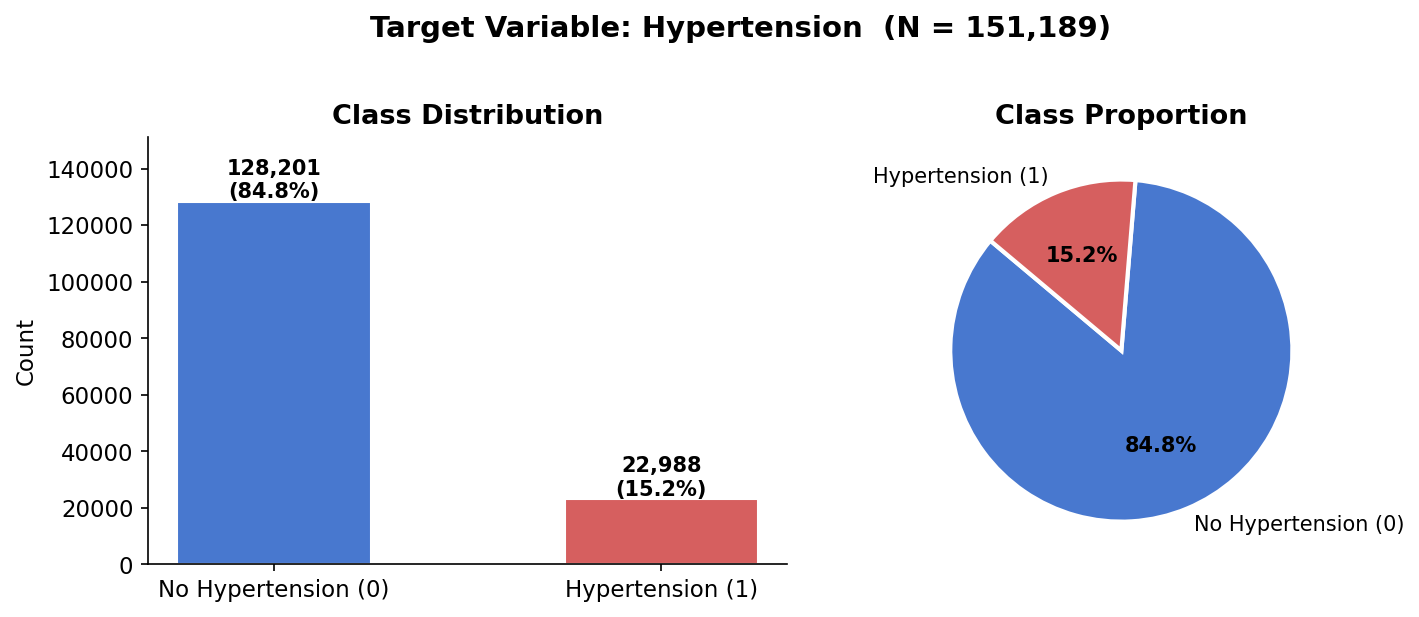

Imbalance ratio  : 5.58  |  Minority class: 1 (22,988)


In [17]:
# ── 2. Target Distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
vc    = y.value_counts().sort_index()
labels = ['No Hypertension (0)', 'Hypertension (1)']
bars  = axes[0].bar(labels, vc.values, color=PALETTE2, edgecolor='white', width=0.5)
for bar, cnt in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{cnt:,}\n({cnt/len(y)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, vc.max() * 1.18)
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    vc.values, labels=labels, colors=PALETTE2, autopct='%1.1f%%',
    startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10})
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Class Proportion', fontweight='bold')

fig.suptitle(f'Target Variable: {target_col}  (N = {len(y):,})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig01_target_distribution.png', bbox_inches='tight')
plt.show()

# Class imbalance ratio
ir = vc.max() / vc.min()
print(f"Imbalance ratio  : {ir:.2f}  |  Minority class: {vc.idxmin()} ({vc.min():,})")

Features with missing values: 45 / 54


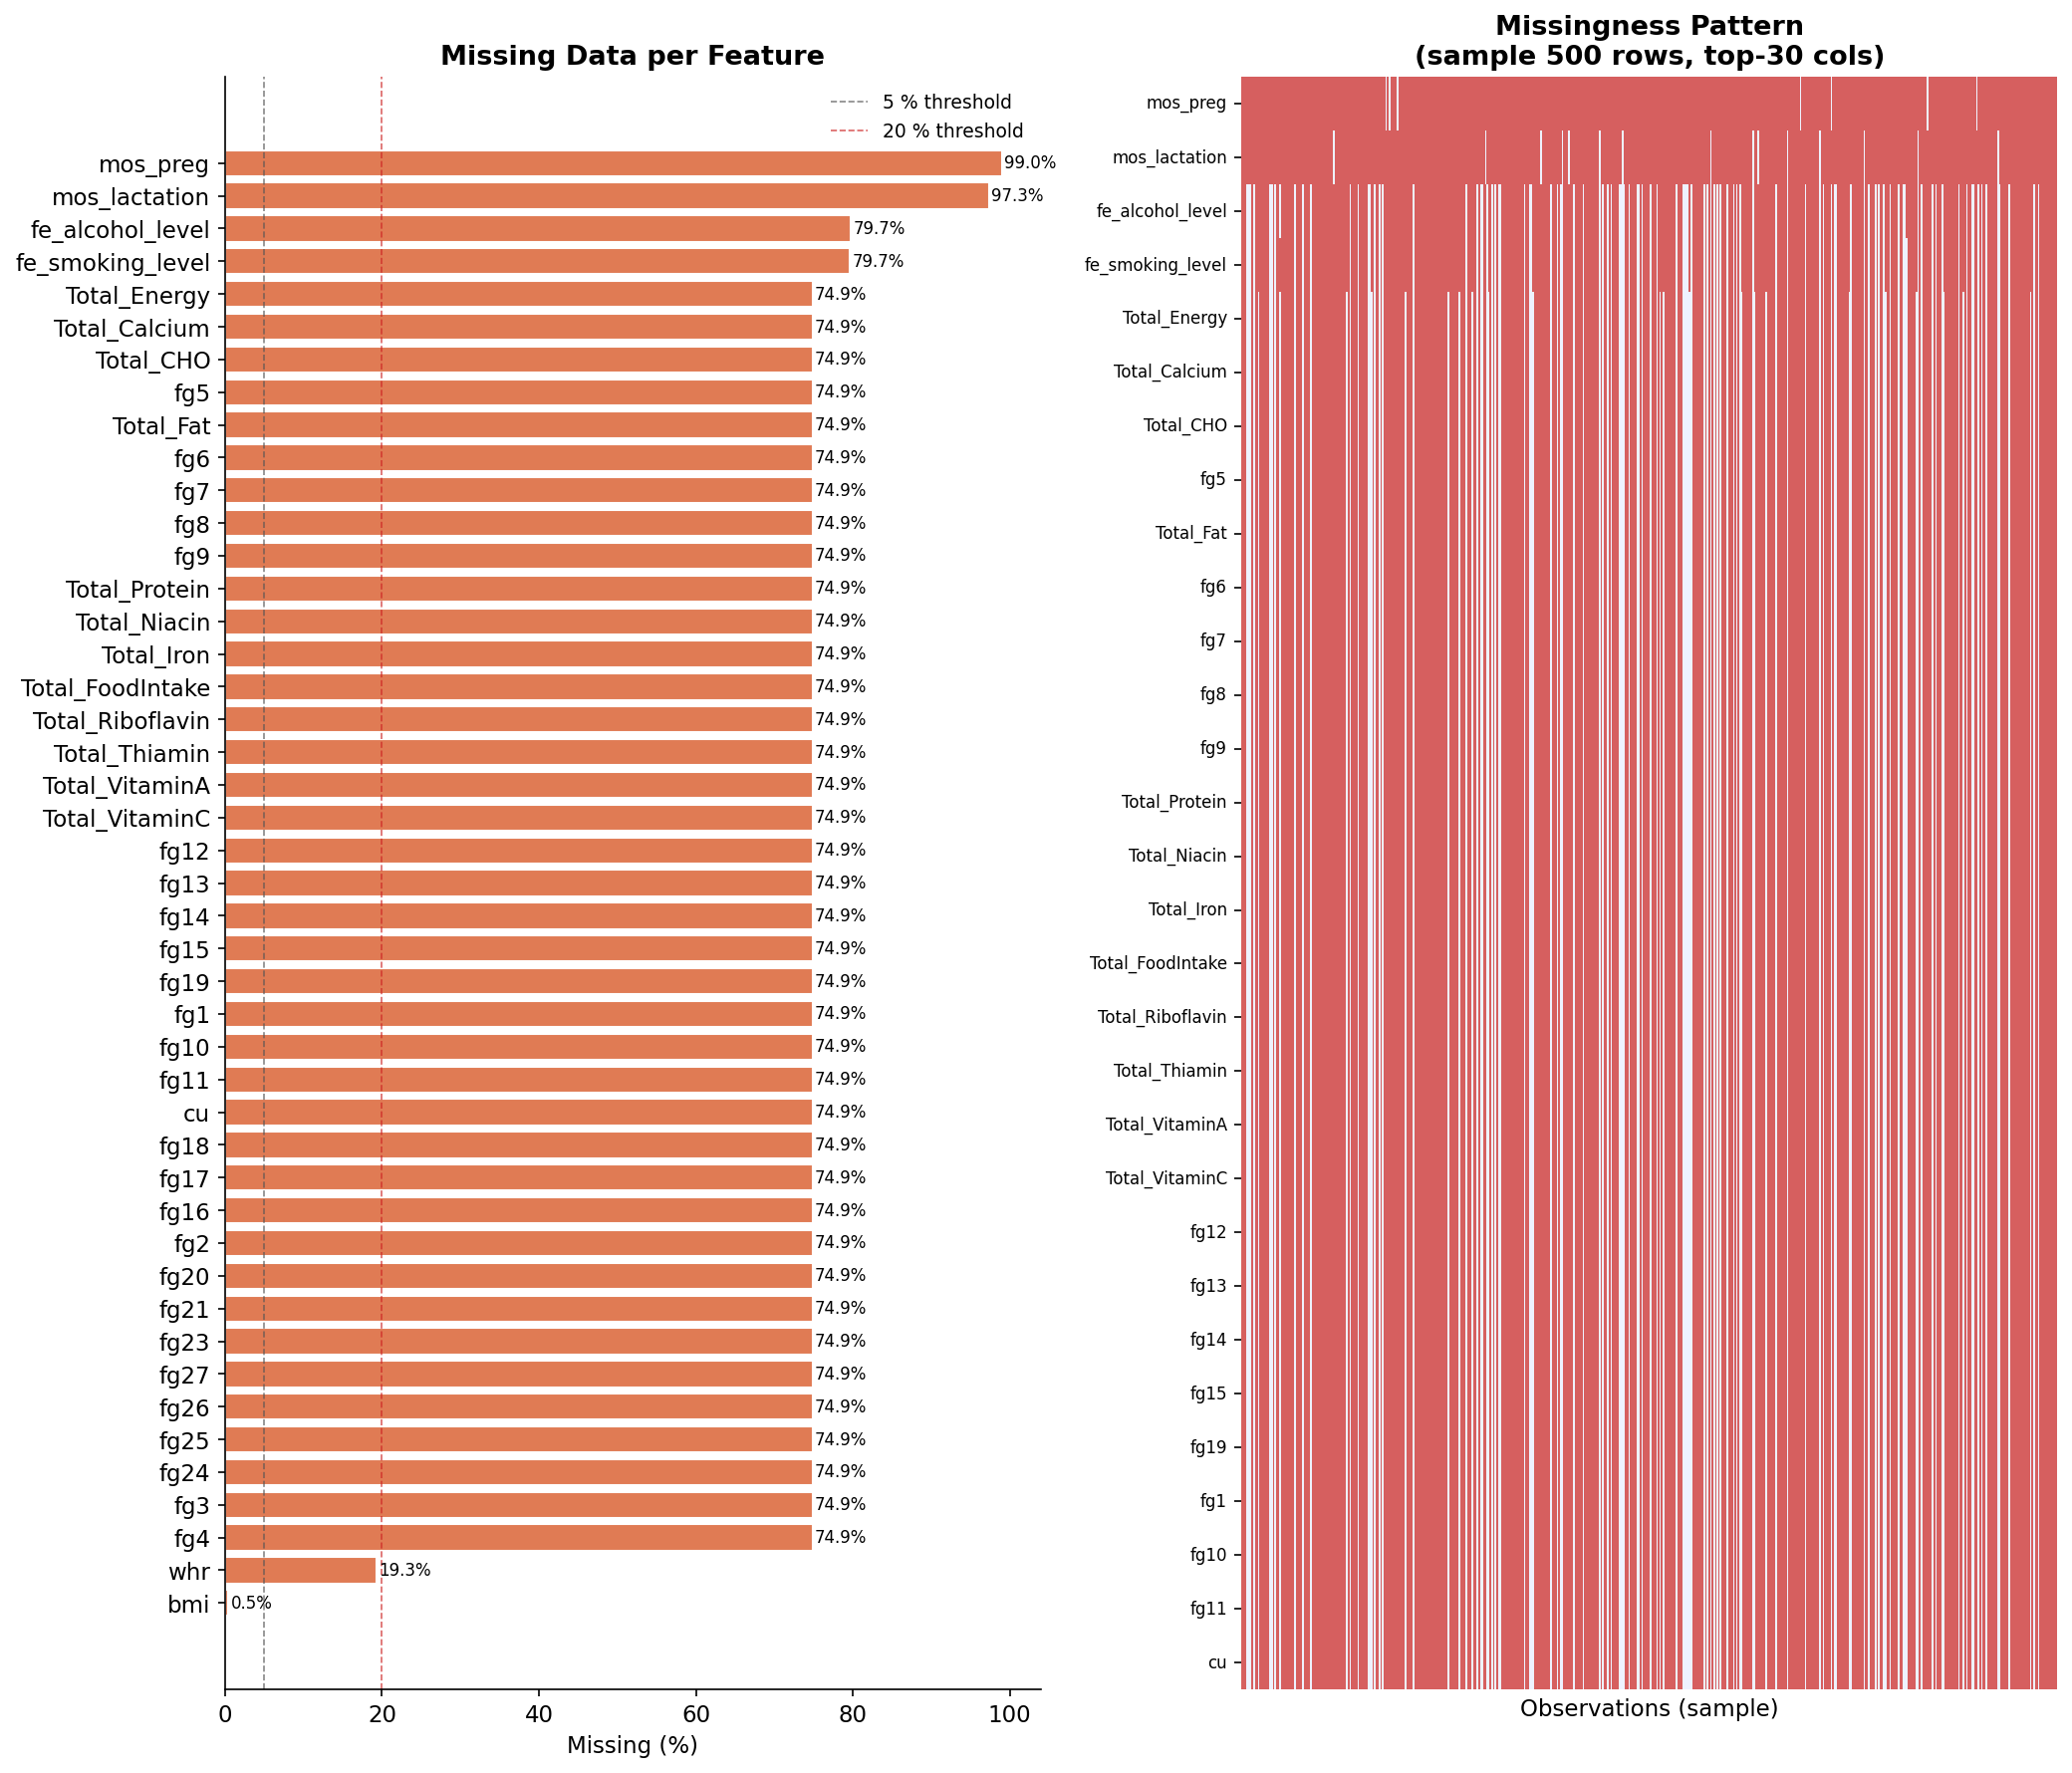

In [18]:
# ── 3. Missing Data Analysis ─────────────────────────────────────────────────
miss = feat_df[feat_df['missing_n'] > 0].sort_values('missing_pct', ascending=False)
print(f"Features with missing values: {len(miss)} / {len(feat_df)}")

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, min(12, len(miss) * 0.32 + 2))))

# Bar chart of % missing per feature
if len(miss) > 0:
    axes[0].barh(miss['feature'], miss['missing_pct'],
                 color='#E07B54', edgecolor='white')
    axes[0].axvline(5, color='#555', linestyle='--', linewidth=0.8, alpha=0.7,
                    label='5 % threshold')
    axes[0].axvline(20, color='#C22', linestyle='--', linewidth=0.8, alpha=0.7,
                    label='20 % threshold')
    for i, (_, row) in enumerate(miss.iterrows()):
        axes[0].text(row['missing_pct'] + 0.3, i,
                     f"{row['missing_pct']:.1f}%", va='center', fontsize=8)
    axes[0].set_xlabel('Missing (%)')
    axes[0].set_title('Missing Data per Feature', fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].invert_yaxis()
else:
    axes[0].text(0.5, 0.5, 'No missing values', ha='center', va='center',
                 transform=axes[0].transAxes, fontsize=13)
    axes[0].set_axis_off()

# Missingness heatmap (up to 30 features for readability)
miss_matrix = eda_df.drop(columns=['__target__']).isnull()
high_miss_cols = miss['feature'].tolist()[:30] if len(miss) > 0 else []
if high_miss_cols:
    sub = miss_matrix[high_miss_cols].astype(int)
    sample_n = min(500, len(sub))
    sub_sample = sub.sample(sample_n, random_state=42)
    sns.heatmap(sub_sample.T, cmap=['#EEF2FF', '#D65F5F'],
                cbar=False, xticklabels=False,
                yticklabels=True, linewidths=0, ax=axes[1])
    axes[1].set_title(f'Missingness Pattern\n(sample {sample_n} rows, top-{len(high_miss_cols)} cols)',
                      fontweight='bold')
    axes[1].set_xlabel('Observations (sample)')
    axes[1].tick_params(axis='y', labelsize=8)
else:
    axes[1].text(0.5, 0.5, 'No missing values\nin dataset', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=13)
    axes[1].set_axis_off()

plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig02_missing_data.png', bbox_inches='tight')
plt.show()

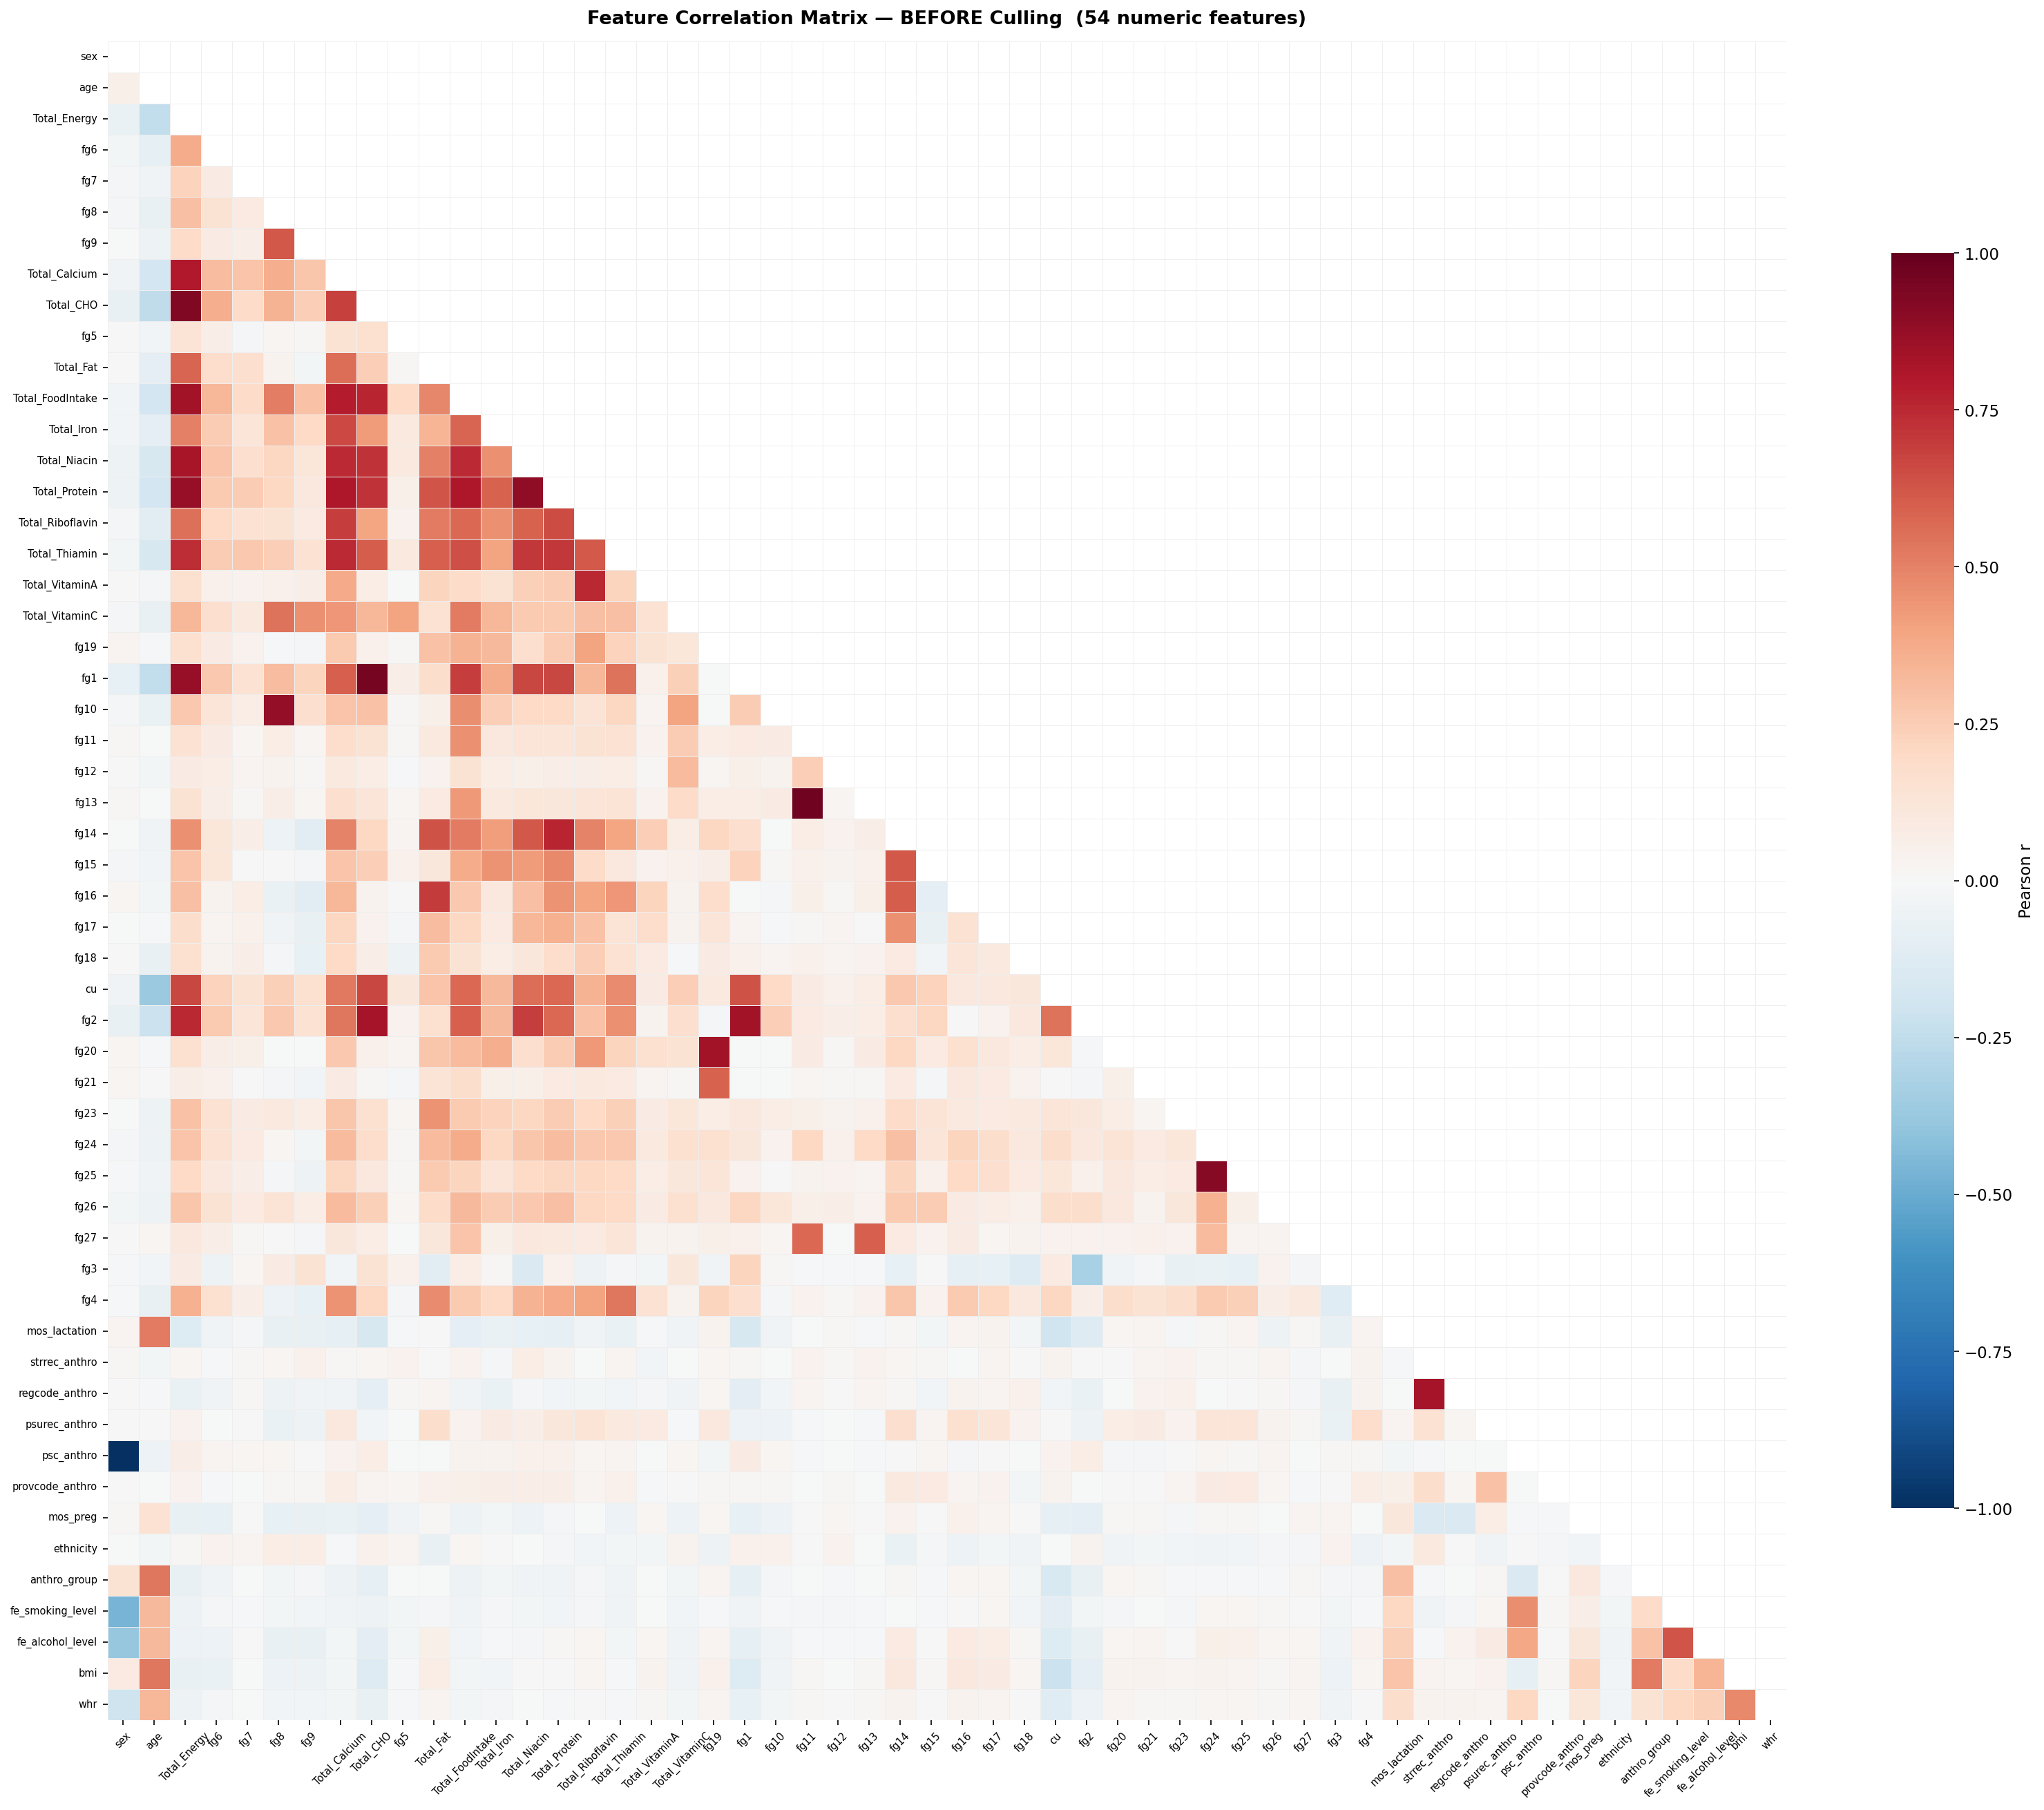


Pairs with |r| ≥ 0.7 (BEFORE culling): 32
  sex                             ↔  psc_anthro                       |r| = 1.0
  fg11                            ↔  fg13                             |r| = 0.974
  Total_CHO                       ↔  fg1                              |r| = 0.958
  Total_Energy                    ↔  Total_CHO                        |r| = 0.929
  fg24                            ↔  fg25                             |r| = 0.912
  Total_Niacin                    ↔  Total_Protein                    |r| = 0.888
  fg8                             ↔  fg10                             |r| = 0.876
  Total_Energy                    ↔  Total_Protein                    |r| = 0.874
  Total_Energy                    ↔  fg1                              |r| = 0.869
  fg19                            ↔  fg20                             |r| = 0.841
  Total_Energy                    ↔  Total_FoodIntake                 |r| = 0.837
  fg1                             ↔  fg2                 

In [19]:
# ── 4a. Collinearity Heatmap — BEFORE Culling ────────────────────────────────
# Uses the imputed training set before the 0.70 cutoff filter was applied.
# We reconstruct using all numeric cols present at imputation time.
_corr_before = X_e3_tr_imp.copy()
# Add back the dropped columns from the imputed frame for the "before" view
_all_num_before = X_e3_tr.select_dtypes(include=np.number).columns.tolist()
# Re-impute dropped cols for visualisation only
_knn_vis = KNNImputer(n_neighbors=5)
_X_before = X_e3_tr[_all_num_before].copy()
_X_before_imp = pd.DataFrame(
    _knn_vis.fit_transform(_X_before), columns=_all_num_before, index=_X_before.index)

corr_before = _X_before_imp.corr()
n_b = len(corr_before)
fig_h = max(8, n_b * 0.38)
fig, ax = plt.subplots(figsize=(fig_h + 1, fig_h))
mask = np.triu(np.ones_like(corr_before, dtype=bool), k=0)   # hide upper triangle + diagonal
sns.heatmap(
    corr_before, mask=mask, annot=(n_b <= 20), fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor='#eee',
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'},
    ax=ax, square=True, annot_kws={'size': 7}
)
ax.set_title(f'Feature Correlation Matrix — BEFORE Culling  ({n_b} numeric features)',
             fontweight='bold', fontsize=13, pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', labelsize=7)

# Annotate pairs above cutoff
high_corr_pairs = []
for i in range(n_b):
    for j in range(i + 1, n_b):
        v = abs(corr_before.iloc[i, j])
        if v >= COLLINEARITY_CUTOFF:
            high_corr_pairs.append((corr_before.columns[i], corr_before.columns[j], round(v, 3)))
high_corr_pairs.sort(key=lambda x: -x[2])

plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig03a_corr_before_culling.png', bbox_inches='tight', dpi=200)
plt.show()
print(f"\nPairs with |r| ≥ {COLLINEARITY_CUTOFF} (BEFORE culling): {len(high_corr_pairs)}")
for a_, b_, v_ in high_corr_pairs[:20]:
    print(f"  {a_:30s}  ↔  {b_:30s}   |r| = {v_}")

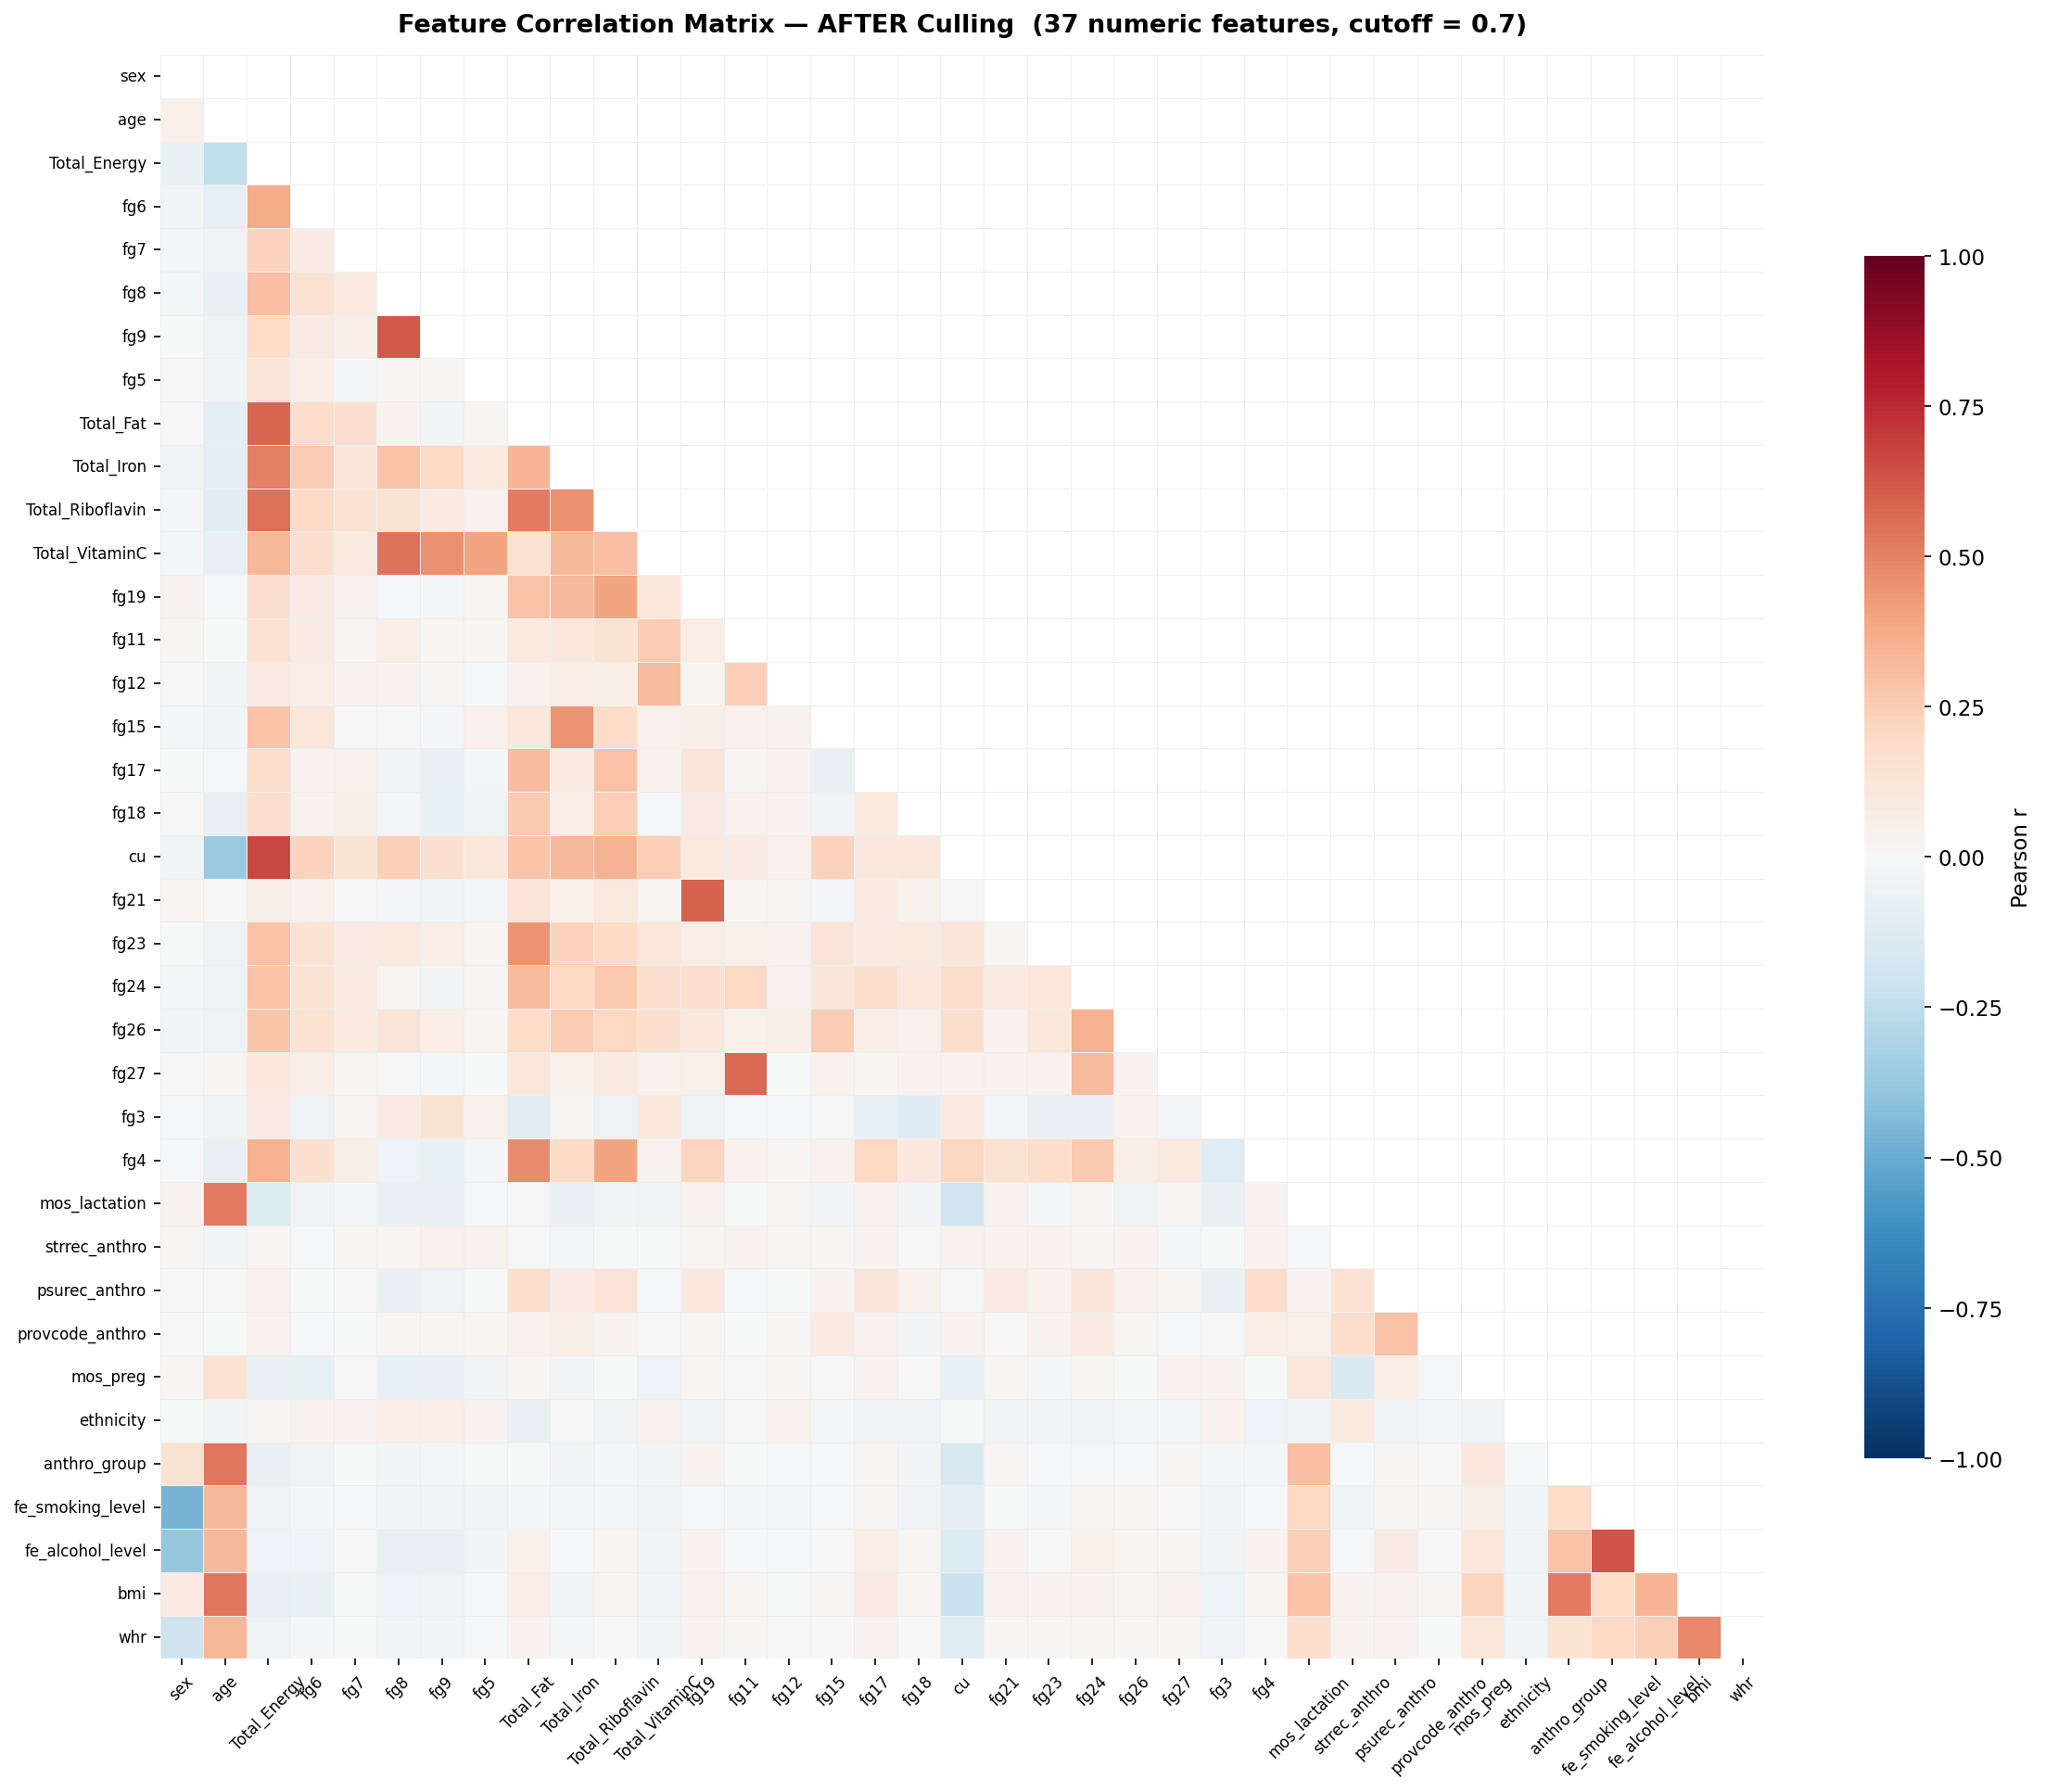

Features removed by collinearity filter: 17  (['sex', 'age', 'Total_Energy', 'fg6', 'fg7', 'fg8', 'fg9', 'Total_Calcium', 'Total_CHO', 'fg5', 'Total_Fat', 'Total_FoodIntake', 'Total_Iron', 'Total_Niacin', 'Total_Protein', 'Total_Riboflavin', 'Total_Thiamin', 'Total_VitaminA', 'Total_VitaminC', 'fg19', 'fg1', 'fg10', 'fg11', 'fg12', 'fg13', 'fg14', 'fg15', 'fg16', 'fg17', 'fg18', 'cu', 'fg2', 'fg20', 'fg21', 'fg23', 'fg24', 'fg25', 'fg26', 'fg27', 'fg3', 'fg4', 'mos_lactation', 'strrec_anthro', 'regcode_anthro', 'psurec_anthro', 'psc_anthro', 'provcode_anthro', 'mos_preg', 'ethnicity', 'anthro_group', 'fe_smoking_level', 'fe_alcohol_level', 'bmi', 'whr']  →  ['sex', 'age', 'Total_Energy', 'fg6', 'fg7', 'fg8', 'fg9', 'fg5', 'Total_Fat', 'Total_Iron', 'Total_Riboflavin', 'Total_VitaminC', 'fg19', 'fg11', 'fg12', 'fg15', 'fg17', 'fg18', 'cu', 'fg21', 'fg23', 'fg24', 'fg26', 'fg27', 'fg3', 'fg4', 'mos_lactation', 'strrec_anthro', 'psurec_anthro', 'provcode_anthro', 'mos_preg', 'ethnicity', 

In [20]:
# ── 4b. Collinearity Heatmap — AFTER Culling ─────────────────────────────────
# e3_num_cols was updated in-place by the collinearity filter cell above (cutoff 0.70)
corr_after = X_e3_tr_imp[e3_num_cols].corr()
n_a = len(corr_after)
fig_h2 = max(6, n_a * 0.40)
fig, ax = plt.subplots(figsize=(fig_h2 + 1, fig_h2))
mask_a = np.triu(np.ones_like(corr_after, dtype=bool), k=0)
sns.heatmap(
    corr_after, mask=mask_a, annot=(n_a <= 25), fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor='#eee',
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'},
    ax=ax, square=True, annot_kws={'size': 8}
)
ax.set_title(f'Feature Correlation Matrix — AFTER Culling  ({n_a} numeric features, cutoff = {COLLINEARITY_CUTOFF})',
             fontweight='bold', fontsize=13, pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig03b_corr_after_culling.png', bbox_inches='tight', dpi=200)
plt.show()

dropped_n = len(_all_num_before) - n_a
print(f"Features removed by collinearity filter: {dropped_n}  ({_all_num_before}  →  {e3_num_cols})")
if _e3_drop:
    print("Dropped:", _e3_drop)
if _e3_protected:
    print("Protected (never dropped):", _e3_protected)

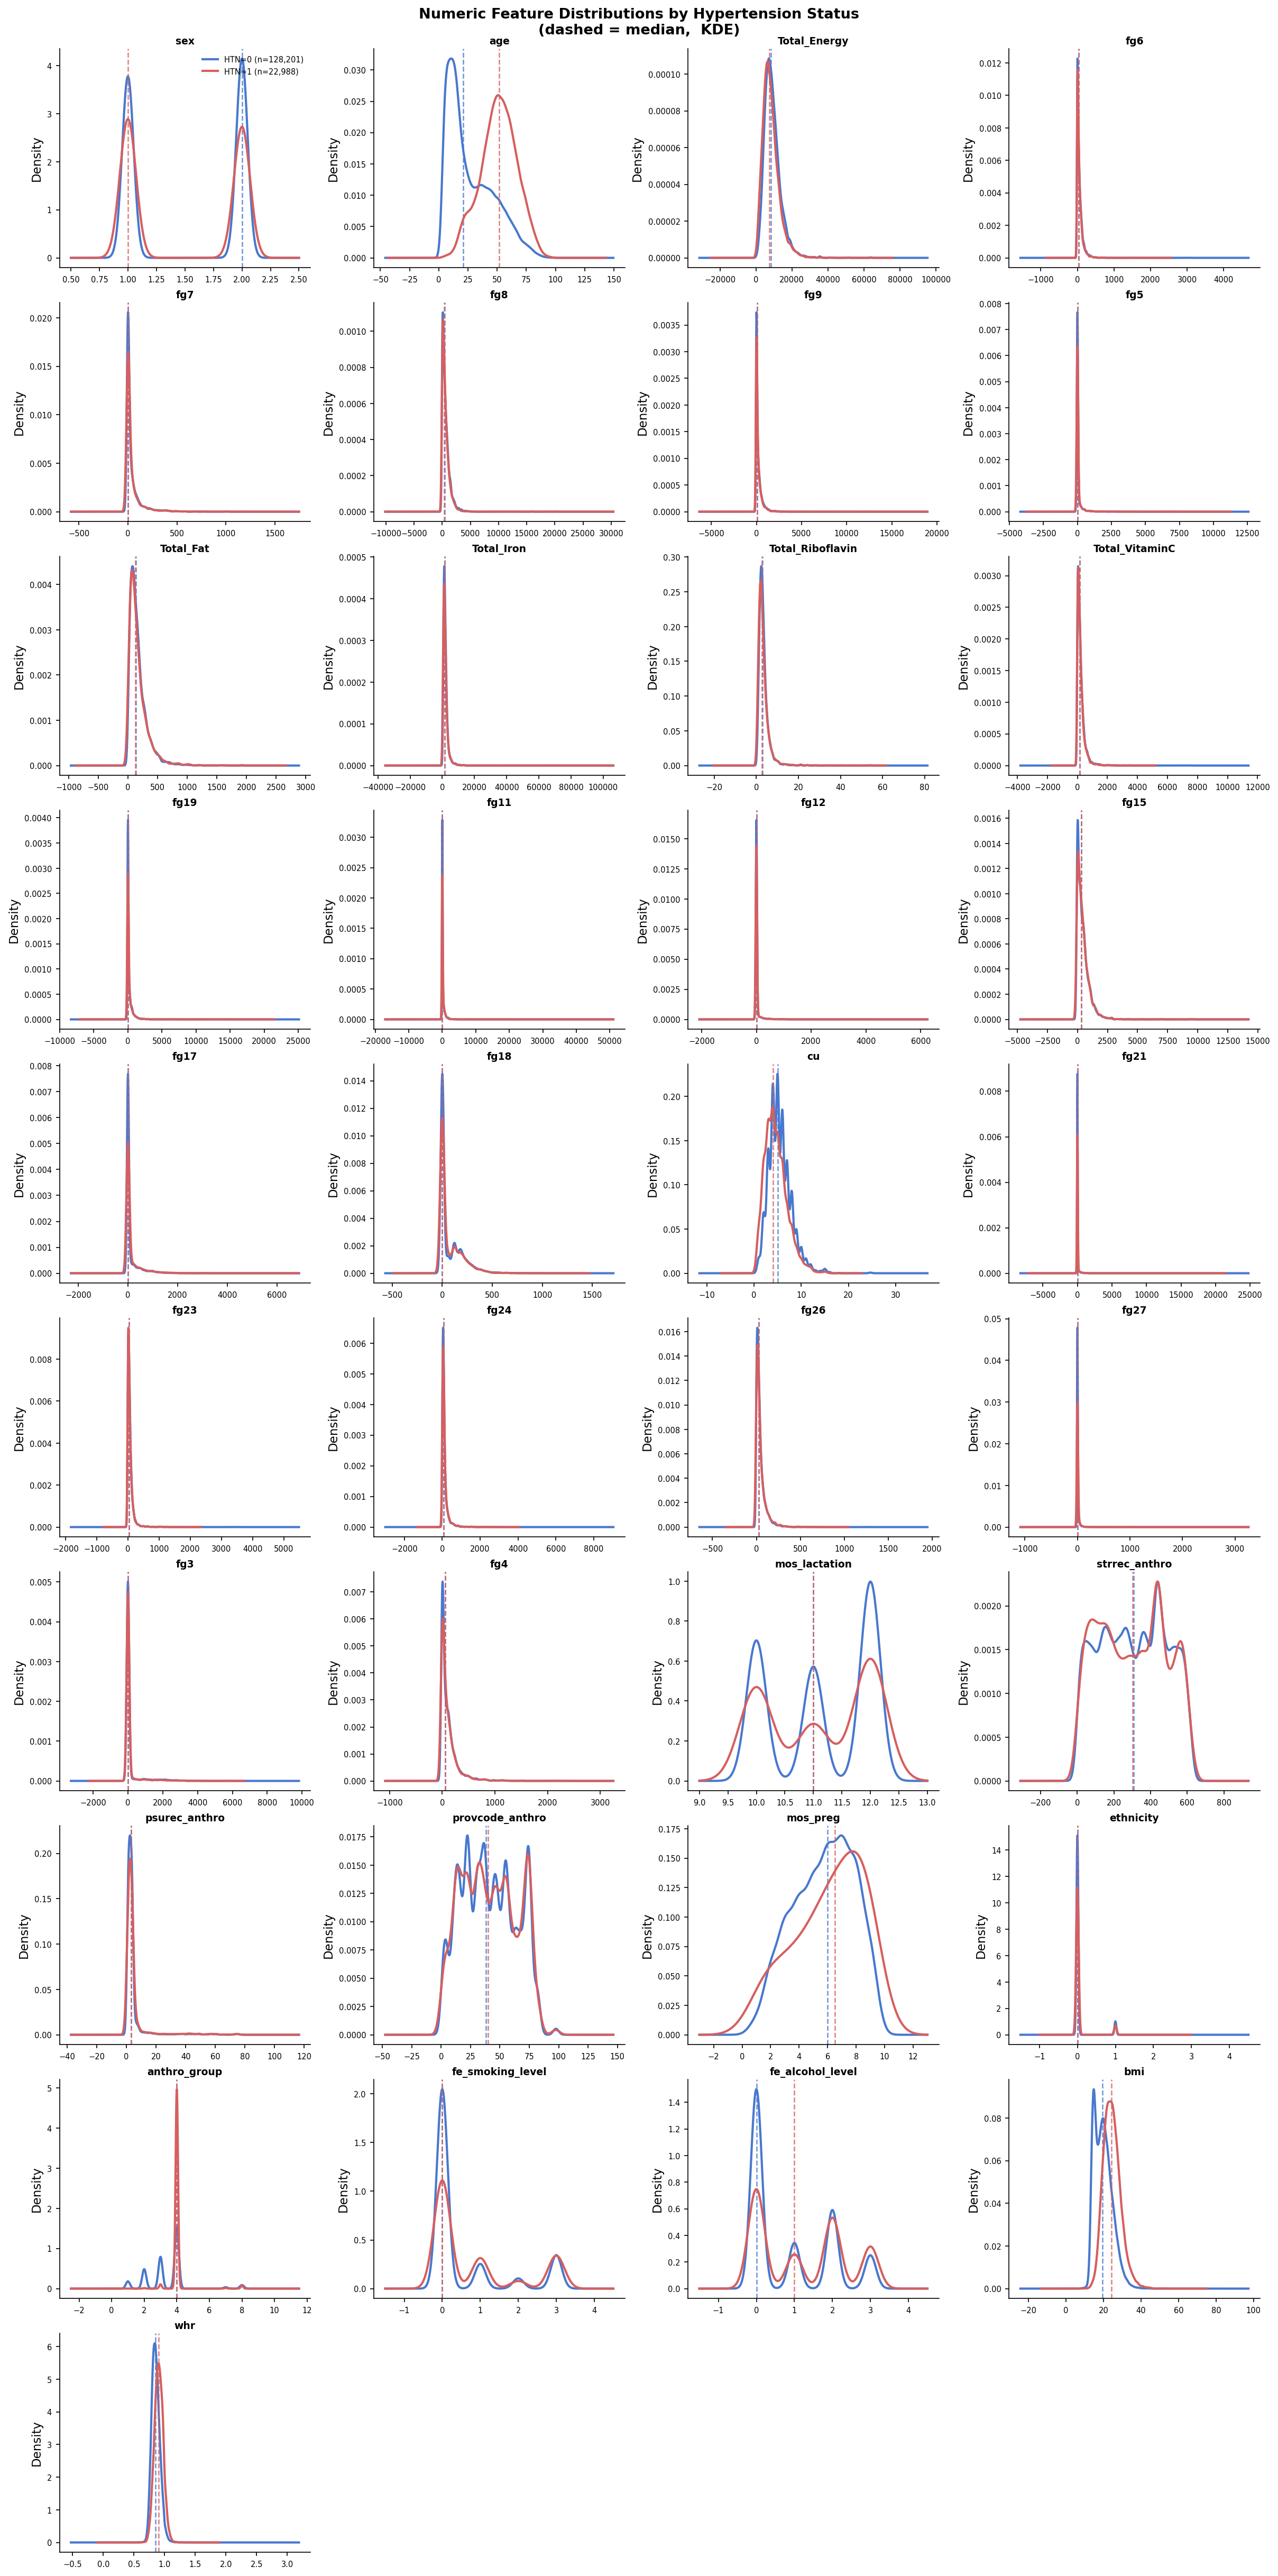

In [21]:
# ── 5. Numeric Feature Distributions (post-cull) — KDE by Target Class ───────
# Shows distributional separation between HTN=0 and HTN=1 for every retained numeric feature.
plot_num = e3_num_cols   # post-cull set
n_feats  = len(plot_num)
ncols    = 4
nrows    = int(np.ceil(n_feats / ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 4, nrows * 3.2),
                         constrained_layout=True)
axes_flat = np.array(axes).ravel()

for i, col in enumerate(plot_num):
    ax = axes_flat[i]
    for cls, color in PALETTE.items():
        subset = eda_df.loc[eda_df['__target__'] == cls, col].dropna()
        label  = f"HTN={cls} (n={len(subset):,})"
        subset.plot.kde(ax=ax, color=color, linewidth=2, label=label,
                        bw_method='silverman')
        ax.axvline(subset.median(), color=color, linestyle='--',
                   linewidth=1.2, alpha=0.8)
    ax.set_title(col, fontsize=9, fontweight='bold', pad=4)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')
    else:
        ax.get_legend().remove() if ax.get_legend() else None

# Hide empty axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Numeric Feature Distributions by Hypertension Status\n'
             '(dashed = median,  KDE)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(PLOT_DIR / 'fig04_numeric_kde_by_target.png', bbox_inches='tight', dpi=200)
plt.show()

         feature    type  statistic           metric  abs_stat  p_value
             age numeric     0.4138 Point-biserial r    0.4138   0.0000
             bmi numeric     0.3344 Point-biserial r    0.3344   0.0000
             whr numeric     0.2681 Point-biserial r    0.2681   0.0000
    anthro_group numeric     0.1879 Point-biserial r    0.1879   0.0000
fe_alcohol_level numeric     0.1356 Point-biserial r    0.1356   0.0000
              cu numeric    -0.1251 Point-biserial r    0.1251   0.0000
fe_smoking_level numeric     0.0962 Point-biserial r    0.0962   0.0000
             fg1 numeric    -0.0876 Point-biserial r    0.0876   0.0000
       Total_CHO numeric    -0.0866 Point-biserial r    0.0866   0.0000
    Total_Energy numeric    -0.0718 Point-biserial r    0.0718   0.0000
             fg2 numeric    -0.0695 Point-biserial r    0.0695   0.0000
Total_FoodIntake numeric    -0.0468 Point-biserial r    0.0468   0.0000
   Total_Calcium numeric    -0.0400 Point-biserial r    0.0400  

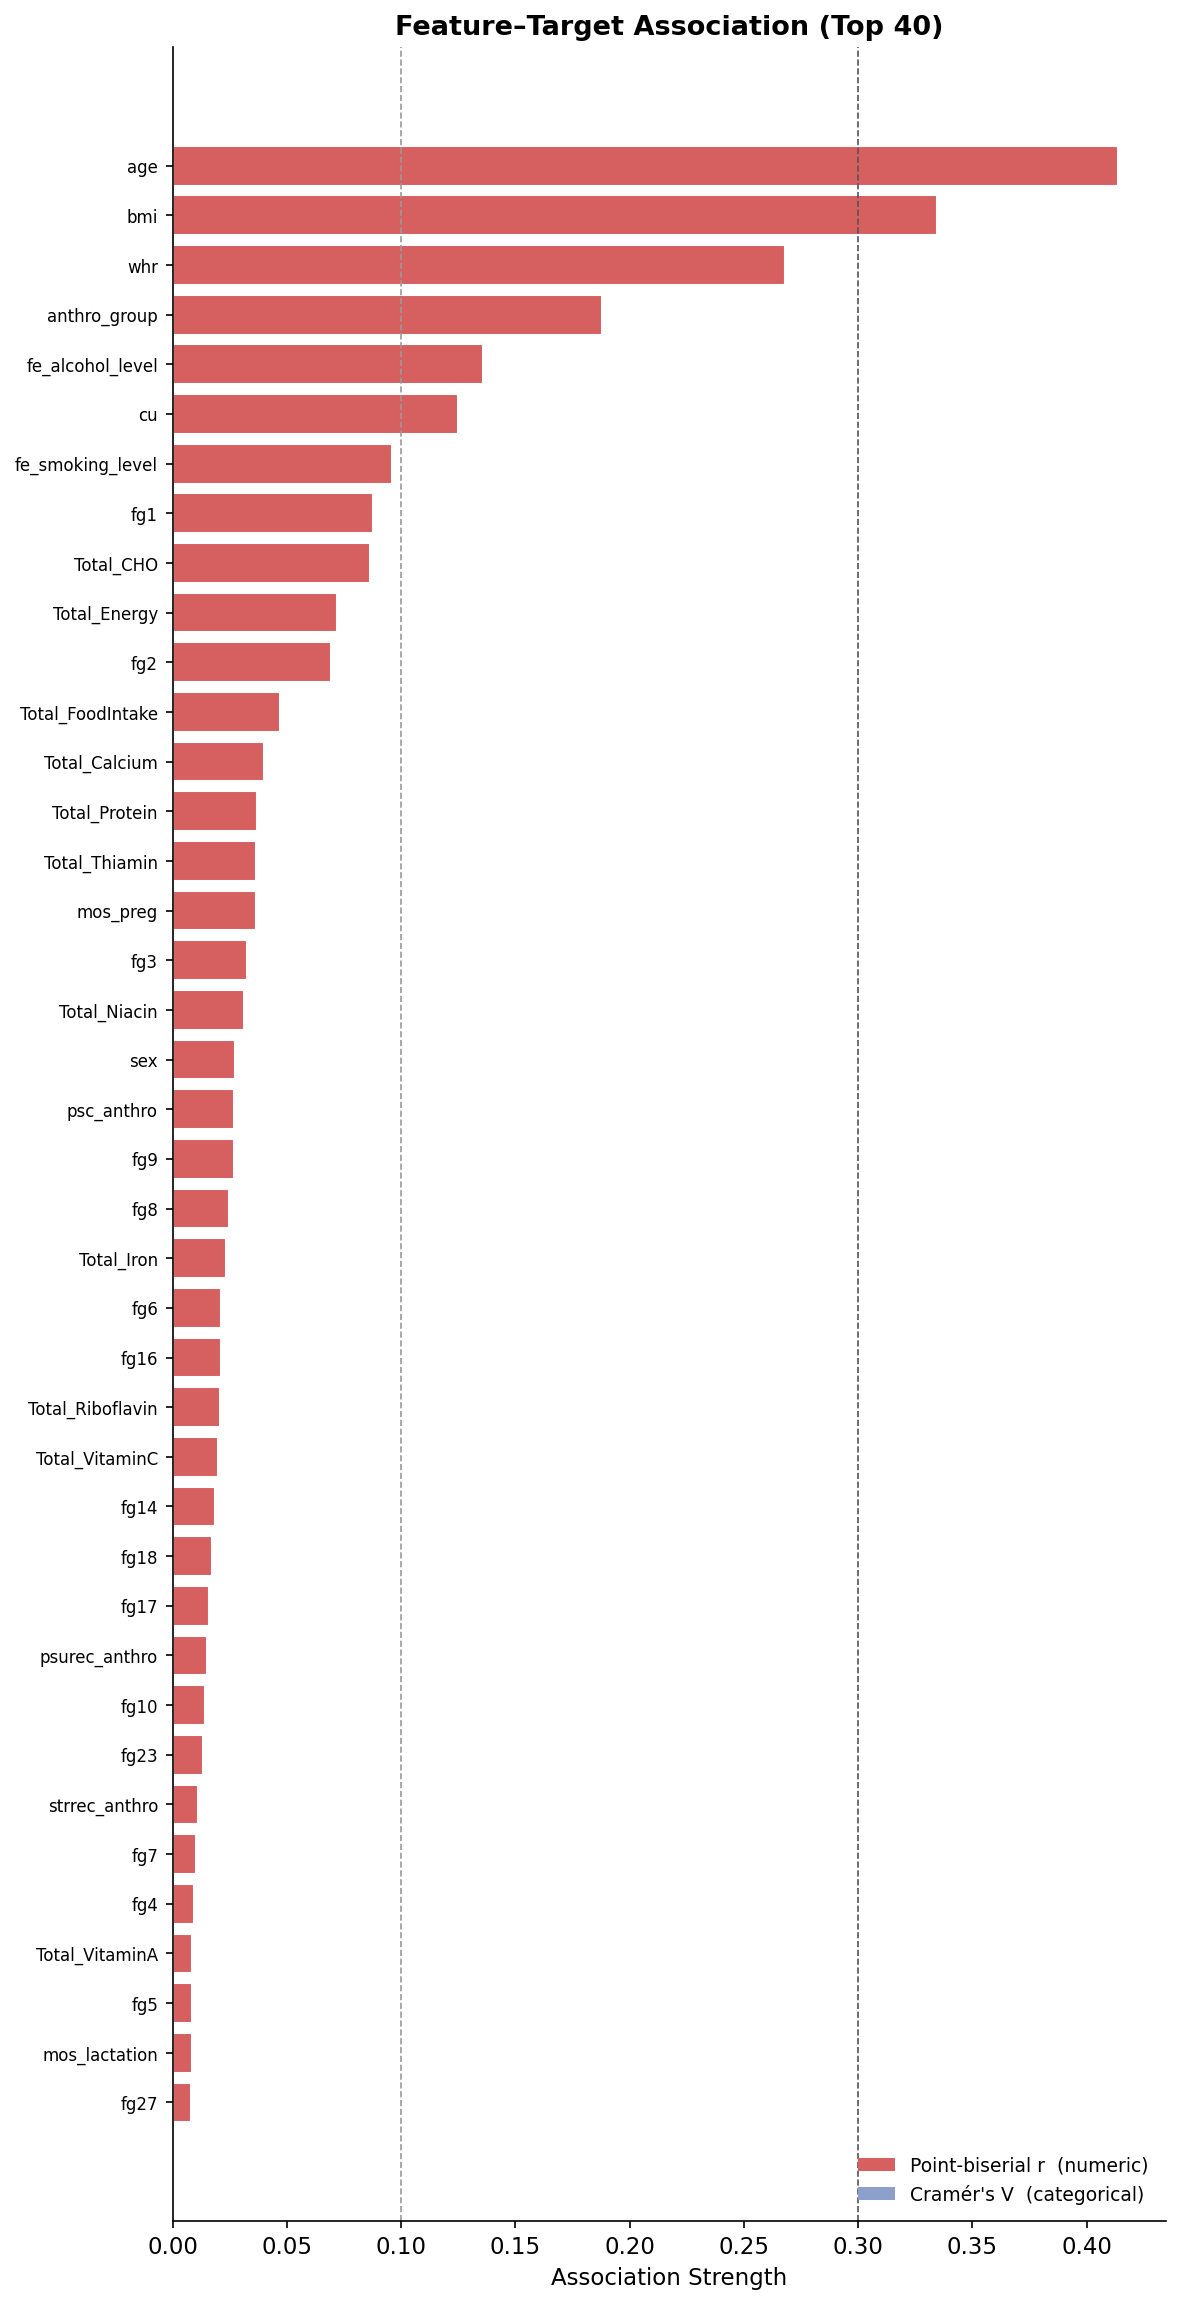

In [22]:
# ── 6. Feature–Target Association Ranking ────────────────────────────────────
# Point-biserial r for numeric features, Cramér's V for categorical.
assoc_rows = []

# Numeric: point-biserial correlation
eda_y = eda_df['__target__'].values
for col in num_cols_raw:
    vals = eda_df[col].values
    valid = ~(np.isnan(vals) | np.isnan(eda_y.astype(float)))
    if valid.sum() < 30:
        continue
    r, p = pointbiserialr(vals[valid], eda_y[valid])
    assoc_rows.append({'feature': col, 'type': 'numeric',
                       'statistic': round(r, 4), 'metric': 'Point-biserial r',
                       'abs_stat': abs(r), 'p_value': p})

# Categorical: Cramér's V
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n   = ct.sum().sum()
    phi = np.sqrt(chi2 / n)
    k   = min(ct.shape) - 1
    return float(phi / np.sqrt(k)) if k > 0 else 0.0

for col in cat_cols_raw:
    vals = eda_df[col].dropna()
    if len(vals) < 30:
        continue
    y_aligned = eda_df.loc[vals.index, '__target__']
    v = cramers_v(vals, y_aligned)
    assoc_rows.append({'feature': col, 'type': 'categorical',
                       'statistic': round(v, 4), 'metric': "Cramér's V",
                       'abs_stat': v, 'p_value': np.nan})

assoc_df = pd.DataFrame(assoc_rows).sort_values('abs_stat', ascending=False).reset_index(drop=True)
print(assoc_df.to_string(index=False))

# ── Plot: ranked horizontal bar ───────────────────────────────────────────────
top_n = min(40, len(assoc_df))
plot_a = assoc_df.head(top_n).iloc[::-1]   # reverse for bottom-to-top

bar_colors = ['#D65F5F' if t == 'numeric' else '#8DA0CB' for t in plot_a['type']]
fig, ax = plt.subplots(figsize=(8, top_n * 0.35 + 1.5))
bars = ax.barh(plot_a['feature'], plot_a['abs_stat'], color=bar_colors, edgecolor='white')
ax.axvline(0.1, color='#999', linestyle='--', linewidth=0.8, label='|r| = 0.10')
ax.axvline(0.3, color='#555', linestyle='--', linewidth=0.8, label='|r| = 0.30')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#D65F5F', label="Point-biserial r  (numeric)"),
    Patch(facecolor='#8DA0CB', label="Cramér's V  (categorical)"),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
ax.set_xlabel('Association Strength')
ax.set_title(f'Feature–Target Association (Top {top_n})', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig05_feature_association_ranking.png', bbox_inches='tight', dpi=200)
plt.show()

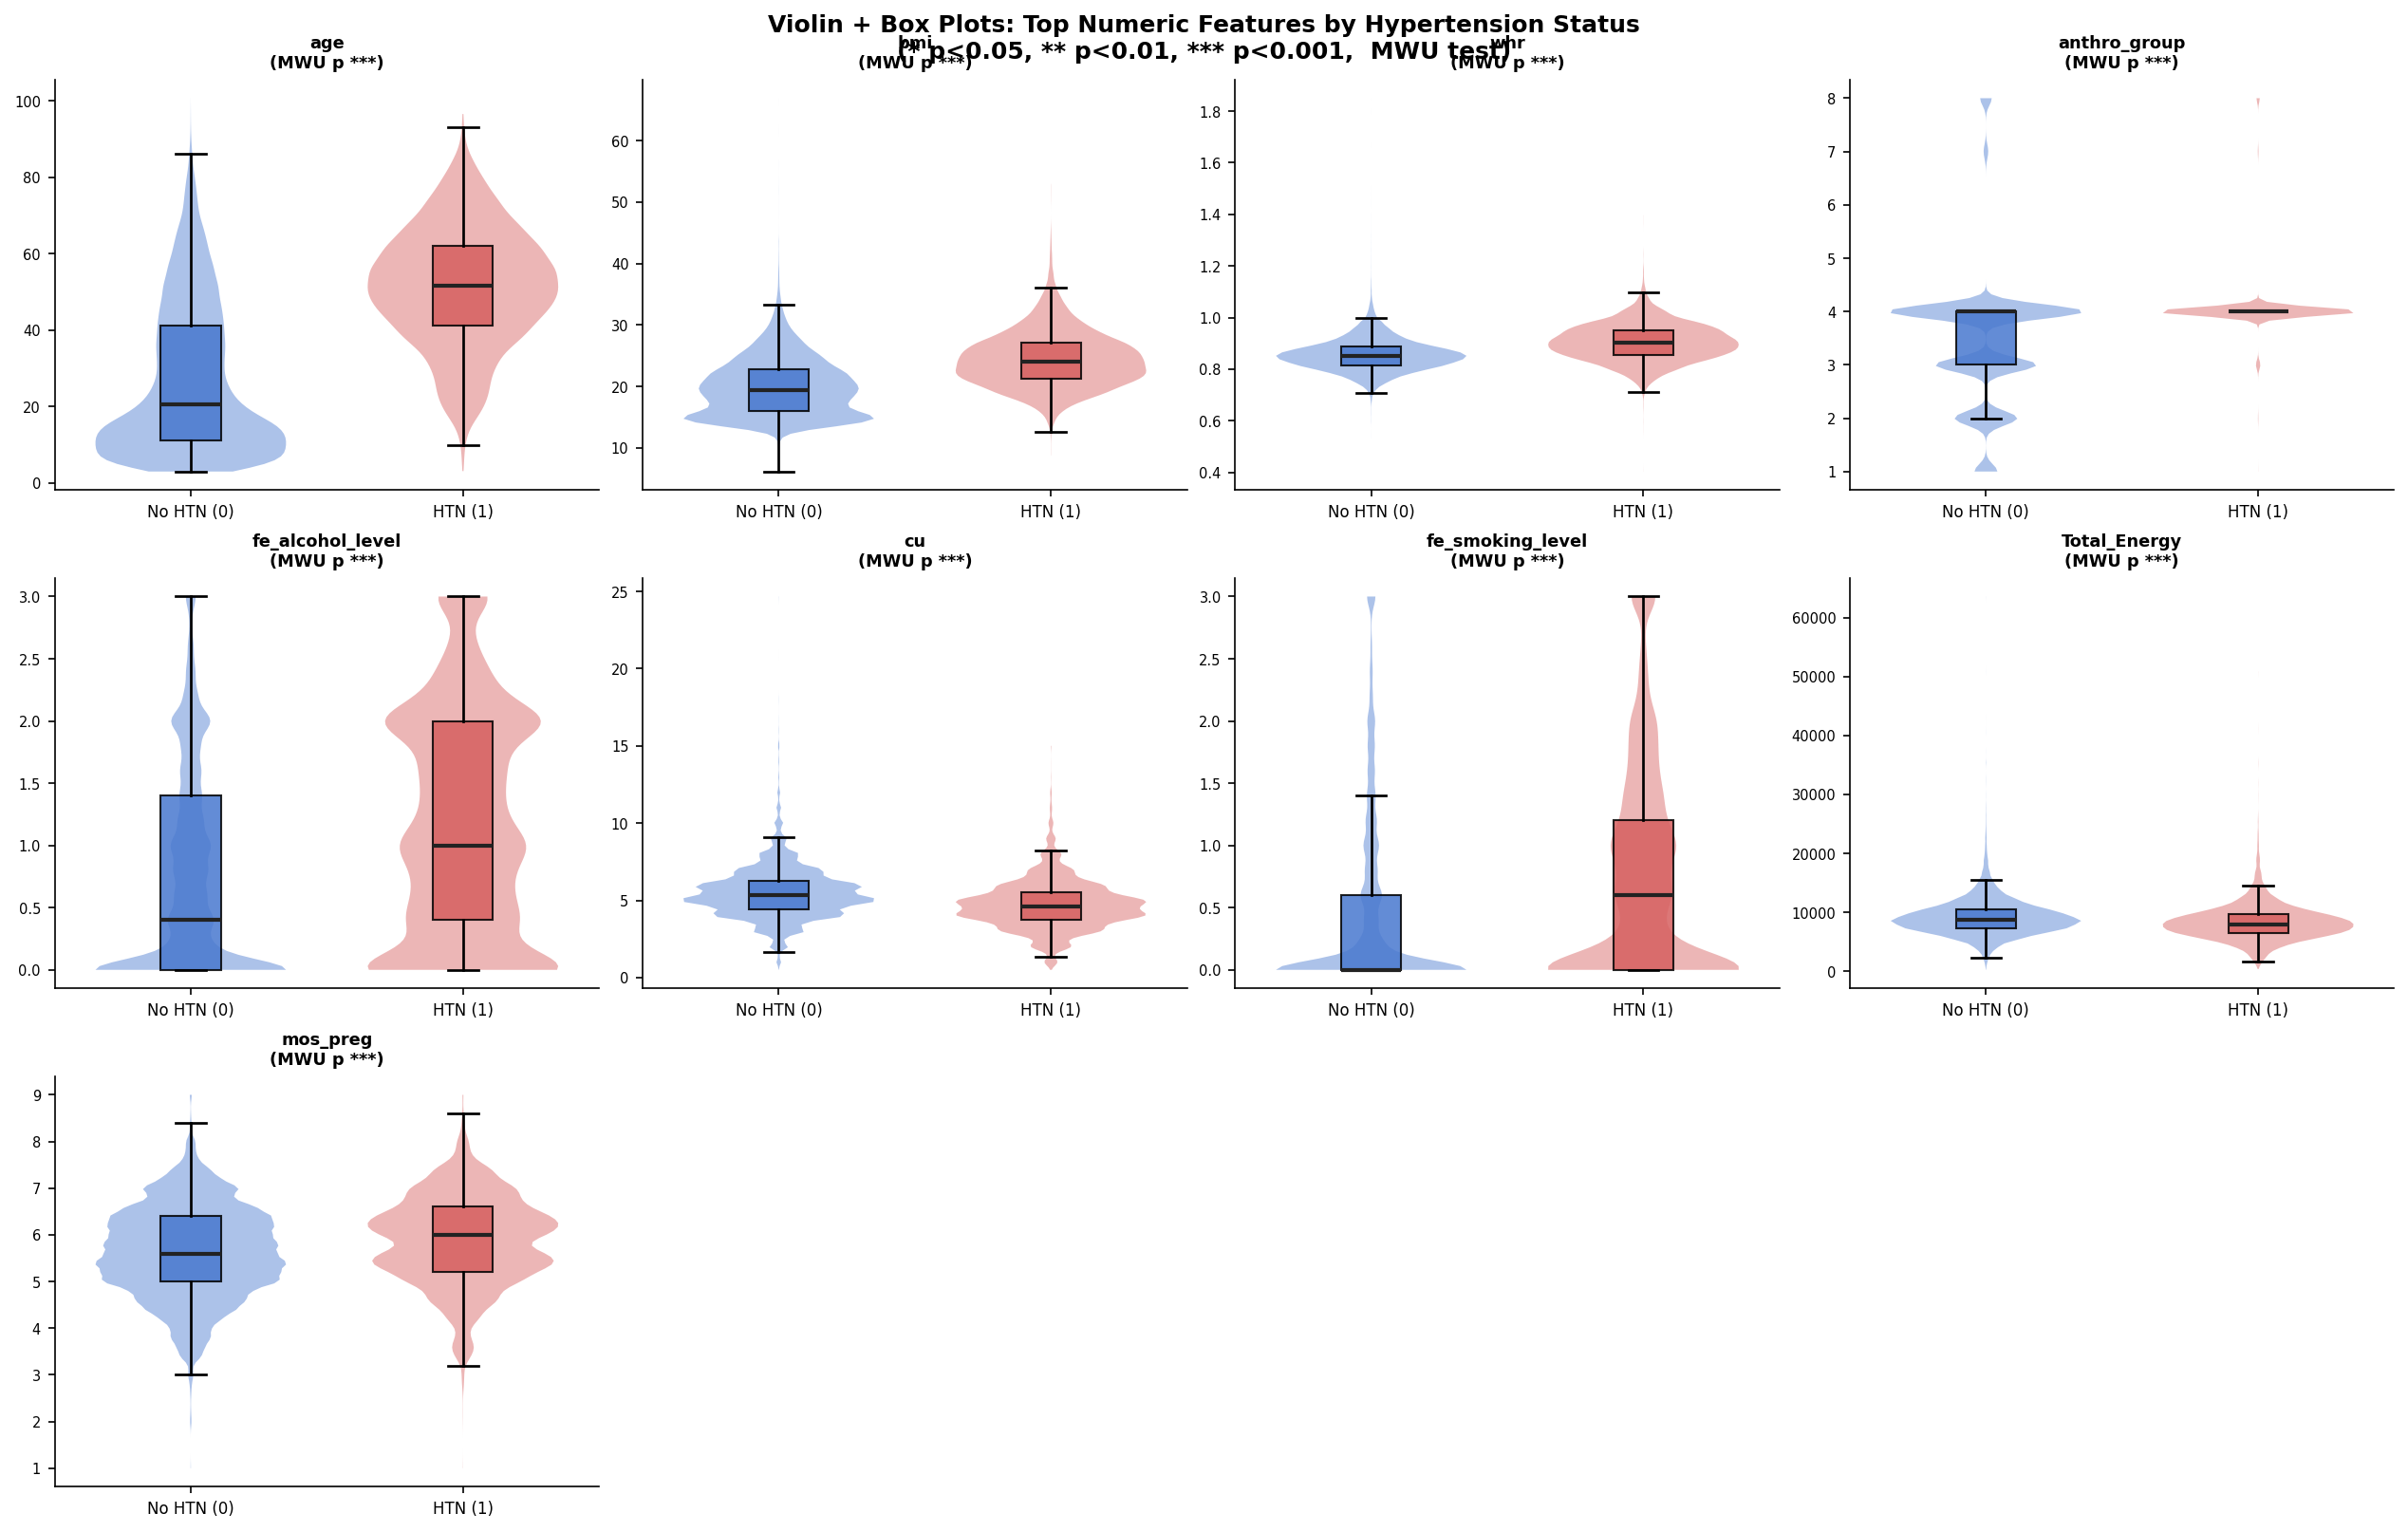

In [23]:
# ── 7. Violin + Box Plots — Top Numeric Features by Target Class ──────────────
# Select top features by association strength (numeric only)
top_num = (assoc_df[assoc_df['type'] == 'numeric']
           .head(min(16, len(e3_num_cols)))['feature'].tolist())
# Clamp to those still in the imputed training set
top_num = [c for c in top_num if c in X_e3_tr_imp.columns]

n_plot = len(top_num)
ncols  = 4
nrows  = int(np.ceil(n_plot / ncols))
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 4.2, nrows * 3.5),
                         constrained_layout=True)
axes_flat = np.array(axes).ravel()

_vdf = X_e3_tr_imp[top_num].copy()
_vdf['__target__'] = y_e3_tr

for i, col in enumerate(top_num):
    ax = axes_flat[i]
    grps = [_vdf.loc[_vdf['__target__'] == cls, col].dropna().values
            for cls in [0, 1]]
    # Violin
    parts = ax.violinplot(grps, positions=[0, 1],
                          showmedians=False, showextrema=False,
                          widths=0.7)
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor(PALETTE2[j])
        pc.set_alpha(0.45)
    # Box overlay
    bp = ax.boxplot(grps, positions=[0, 1], widths=0.22, patch_artist=True,
                    showfliers=False, medianprops=dict(linewidth=2, color='#222'),
                    whiskerprops=dict(linewidth=1.3),
                    capprops=dict(linewidth=1.3))
    for j, box in enumerate(bp['boxes']):
        box.set_facecolor(PALETTE2[j])
        box.set_alpha(0.85)

    # Mann-Whitney U test p-value
    if len(grps[0]) > 1 and len(grps[1]) > 1:
        _, pval = stats.mannwhitneyu(grps[0], grps[1], alternative='two-sided')
        sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
        ax.set_title(f'{col}\n(MWU p {sig})', fontsize=8.5, fontweight='bold')
    else:
        ax.set_title(col, fontsize=8.5, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No HTN (0)', 'HTN (1)'], fontsize=8)
    ax.tick_params(axis='y', labelsize=7)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Violin + Box Plots: Top Numeric Features by Hypertension Status\n'
             '(* p<0.05, ** p<0.01, *** p<0.001,  MWU test)',
             fontsize=12, fontweight='bold', y=1.01)
plt.savefig(PLOT_DIR / 'fig06_violin_boxplots_by_target.png', bbox_inches='tight', dpi=200)
plt.show()

In [24]:
# ── 8. Categorical Features vs Target ────────────────────────────────────────
# Stacked proportional bar chart: class proportions within each category level.
top_cat = (assoc_df[assoc_df['type'] == 'categorical']
           .head(min(12, len(cat_cols_raw)))['feature'].tolist())

if top_cat:
    ncols = 3
    nrows = int(np.ceil(len(top_cat) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 5, nrows * 3.8),
                             constrained_layout=True)
    axes_flat = np.array(axes).ravel()

    for i, col in enumerate(top_cat):
        ax = axes_flat[i]
        ct = pd.crosstab(eda_df[col], eda_df['__target__'], normalize='index') * 100
        ct = ct.sort_values(1, ascending=False) if 1 in ct.columns else ct
        ct.plot(kind='bar', stacked=True, ax=ax,
                color={0: PALETTE2[0], 1: PALETTE2[1]},
                edgecolor='white', width=0.65, legend=(i == 0))
        ax.set_title(col, fontsize=9, fontweight='bold')
        ax.set_ylabel('Proportion (%)' if i % ncols == 0 else '')
        ax.set_xlabel('')
        ax.axhline(y=vc[1] / len(y) * 100,
                   color='#555', linestyle='--', linewidth=0.9,
                   alpha=0.7, label='Overall HTN %')
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.set_ylim(0, 110)
        if i == 0:
            ax.legend(title='HTN', fontsize=8, loc='upper right')

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle('Categorical Features: Hypertension Proportion by Category Level\n'
                 '(dashed = overall HTN prevalence)',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.savefig(PLOT_DIR / 'fig07_cat_features_by_target.png', bbox_inches='tight', dpi=200)
    plt.show()
else:
    print("No categorical features found — skipping this plot.")

No categorical features found — skipping this plot.


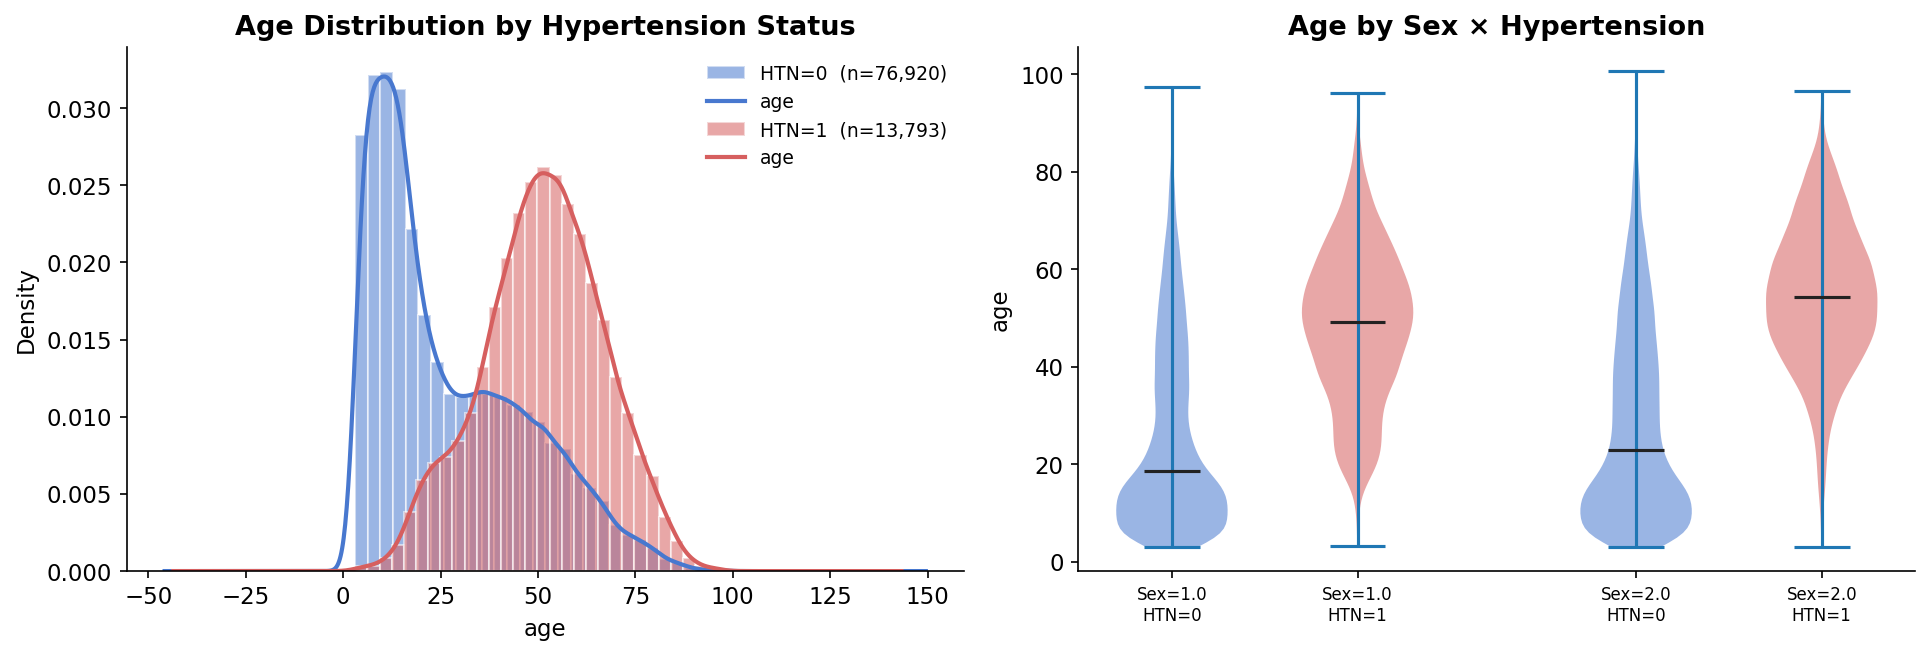

In [25]:
# ── 9a. Age Distribution by Sex & Hypertension Status ─────────────────────────
_demo = X_e3_tr_imp.copy()
_demo['__target__'] = y_e3_tr

# Detect canonical age & sex columns
_age_col = next((c for c in _demo.columns if c.lower() == 'age'), None) or \
           next((c for c in _demo.columns if 'age' in c.lower()), None)
_sex_col = next((c for c in _demo.columns if c.lower() == 'sex'), None) or \
           next((c for c in _demo.columns if 'sex' in c.lower()), None)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Age histogram by hypertension
if _age_col:
    for cls, color in PALETTE.items():
        sub = _demo.loc[_demo['__target__'] == cls, _age_col].dropna()
        axes[0].hist(sub, bins=30, alpha=0.55, color=color, edgecolor='white',
                     label=f'HTN={cls}  (n={len(sub):,})', density=True)
        sub.plot.kde(ax=axes[0], color=color, linewidth=2)
    axes[0].set_title(f'Age Distribution by Hypertension Status', fontweight='bold')
    axes[0].set_xlabel(_age_col)
    axes[0].set_ylabel('Density')
    axes[0].legend(fontsize=9)
else:
    axes[0].text(0.5, 0.5, 'Age column not found', ha='center', va='center',
                 transform=axes[0].transAxes)
    axes[0].set_axis_off()

# Age × Sex grouped violin
if _age_col and _sex_col:
    sex_labels = sorted(_demo[_sex_col].dropna().unique())
    xs, ys, colors = [], [], []
    positions, xtick_pos, xtick_lab = [], [], []
    pos = 0
    for sex in sex_labels:
        for cls in [0, 1]:
            sub = _demo.loc[(_demo[_sex_col] == sex) & (_demo['__target__'] == cls), _age_col].dropna().values
            xs.append(sub)
            ys.append(cls)
            colors.append(PALETTE[cls])
            positions.append(pos)
            xtick_pos.append(pos)
            xtick_lab.append(f"Sex={sex}\nHTN={cls}")
            pos += 1
        xtick_pos[-2] = (xtick_pos[-2] + xtick_pos[-1]) / 2
        del xtick_pos[-1]
        xtick_lab[-2] = f"Sex={sex}"
        del xtick_lab[-1]
        pos += 0.5
    vp = axes[1].violinplot(xs, positions=positions, widths=0.6,
                            showmedians=True, showextrema=True)
    for j, pc in enumerate(vp['bodies']):
        pc.set_facecolor(colors[j])
        pc.set_alpha(0.55)
    vp['cmedians'].set_color('#222')
    axes[1].set_xticks(positions)
    sex_labels_full = [f"Sex={s}\nHTN={c}" for s in sex_labels for c in [0, 1]]
    axes[1].set_xticklabels(sex_labels_full, fontsize=8)
    axes[1].set_title(f'Age by Sex × Hypertension', fontweight='bold')
    axes[1].set_ylabel(_age_col)
elif _age_col:
    axes[1].set_axis_off()
    axes[1].text(0.5, 0.5, 'Sex column not found', ha='center', va='center',
                 transform=axes[1].transAxes)
else:
    axes[1].set_axis_off()

plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig08_age_sex_hypertension.png', bbox_inches='tight', dpi=200)
plt.show()

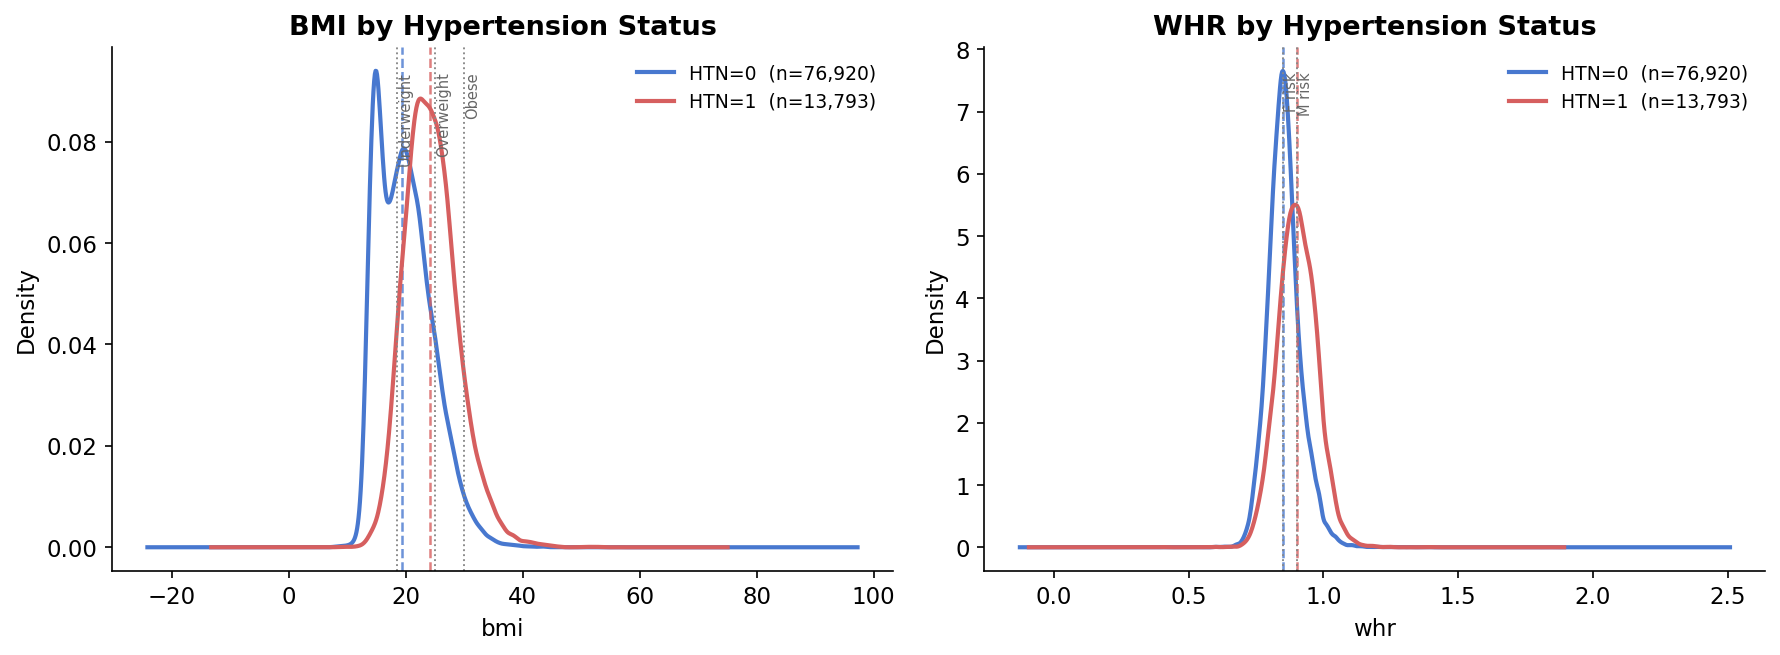

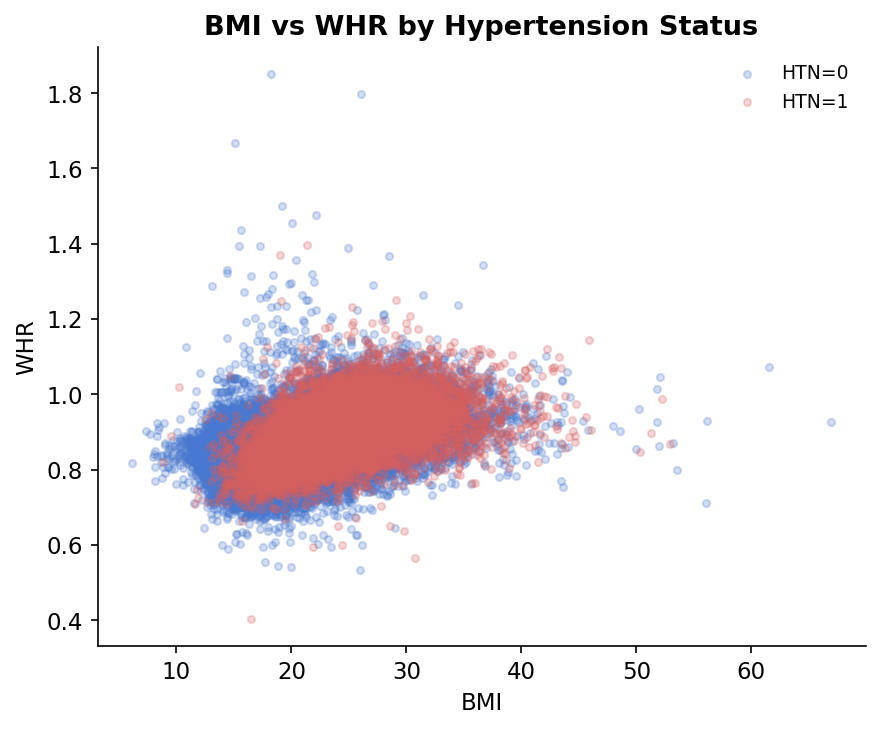

In [26]:
# ── 9b. BMI & WHR — Distribution + Scatter by Hypertension ────────────────────
_bmi_col = next((c for c in _demo.columns if c.lower() == 'bmi'), None)
_whr_col = next((c for c in _demo.columns if c.lower() == 'whr'), None)

available = [c for c in [_bmi_col, _whr_col] if c is not None]

if available:
    ncols = 2
    fig, axes = plt.subplots(1, ncols, figsize=(12, 4.5))

    for k, col in enumerate([_bmi_col, _whr_col]):
        ax = axes[k] if ncols == 2 else axes
        if col is None:
            ax.text(0.5, 0.5, f'{"BMI" if k==0 else "WHR"} not found',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue
        for cls, color in PALETTE.items():
            sub = _demo.loc[_demo['__target__'] == cls, col].dropna()
            sub.plot.kde(ax=ax, color=color, linewidth=2,
                         label=f'HTN={cls}  (n={len(sub):,})')
            ax.axvline(sub.median(), color=color, linestyle='--', linewidth=1.2, alpha=0.8)

        # WHO reference lines
        if col and 'bmi' in col.lower():
            for ref, lbl in [(18.5, 'Underweight'), (25, 'Overweight'), (30, 'Obese')]:
                ax.axvline(ref, color='#888', linestyle=':', linewidth=0.9)
                ax.text(ref + 0.2, ax.get_ylim()[1] * 0.95, lbl, fontsize=7,
                        color='#666', rotation=90, va='top')
        elif col and 'whr' in col.lower():
            for ref, lbl in [(0.85, 'F risk'), (0.90, 'M risk')]:
                ax.axvline(ref, color='#888', linestyle=':', linewidth=0.9)
                ax.text(ref + 0.005, ax.get_ylim()[1] * 0.95, lbl, fontsize=7,
                        color='#666', rotation=90, va='top')
        ax.set_title(f'{col.upper()} by Hypertension Status', fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Density')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'fig09_bmi_whr_by_target.png', bbox_inches='tight', dpi=200)
    plt.show()

# ── BMI × WHR scatter ─────────────────────────────────────────────────────────
if _bmi_col and _whr_col:
    fig, ax = plt.subplots(figsize=(6, 5))
    for cls, color in PALETTE.items():
        sub = _demo[_demo['__target__'] == cls]
        ax.scatter(sub[_bmi_col], sub[_whr_col],
                   c=color, alpha=0.25, s=12, label=f'HTN={cls}', rasterized=True)
    ax.set_xlabel('BMI')
    ax.set_ylabel('WHR')
    ax.set_title('BMI vs WHR by Hypertension Status', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'fig10_bmi_whr_scatter.png', bbox_inches='tight', dpi=200)
    plt.show()
else:
    print("BMI or WHR not available — scatter skipped.")

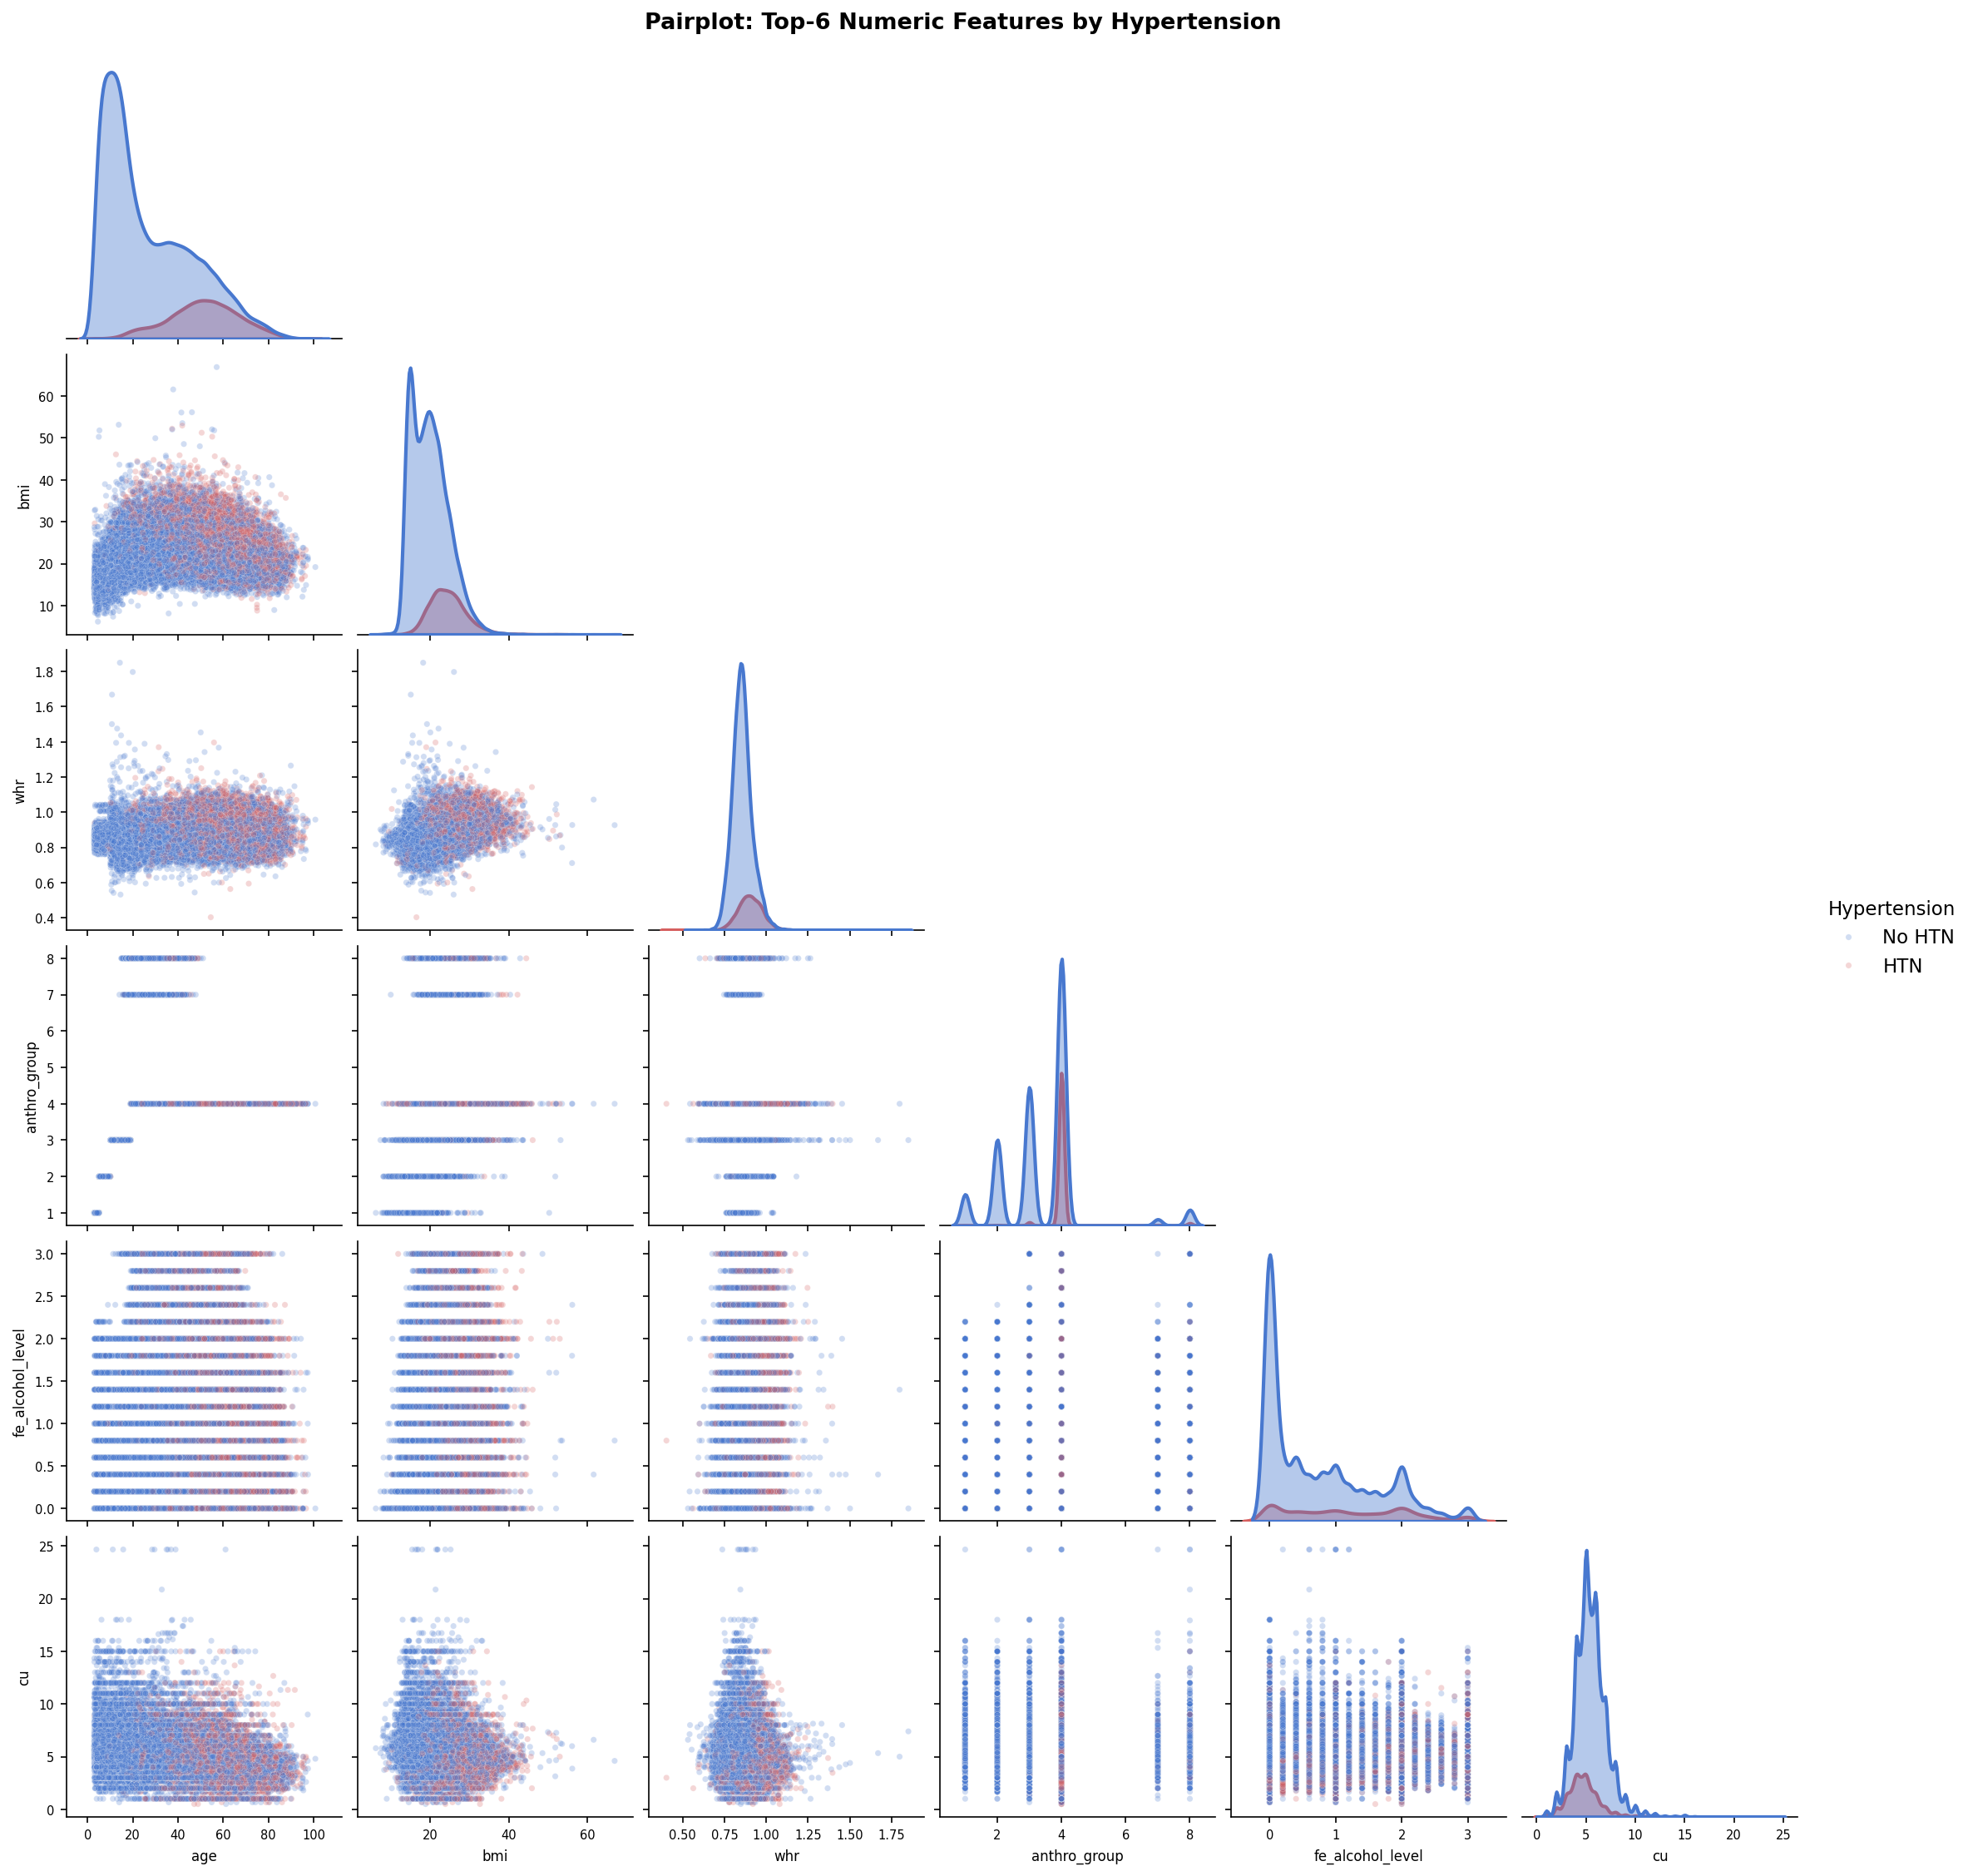

In [27]:
# ── 10. Pairplot — Top-6 Features by Association ─────────────────────────────
top6 = assoc_df[assoc_df['type'] == 'numeric']['feature'].head(6).tolist()
top6 = [c for c in top6 if c in X_e3_tr_imp.columns]

if len(top6) >= 2:
    _pp = X_e3_tr_imp[top6].copy()
    _pp['Hypertension'] = pd.Categorical(
        y_e3_tr, categories=[0, 1]).rename_categories({0: 'No HTN', 1: 'HTN'})
    
    g = sns.pairplot(
        _pp, hue='Hypertension',
        palette={'No HTN': PALETTE2[0], 'HTN': PALETTE2[1]},
        diag_kind='kde', plot_kws={'alpha': 0.25, 's': 12, 'rasterized': True},
        diag_kws={'linewidth': 2, 'fill': True, 'alpha': 0.4},
        corner=True
    )
    g.figure.suptitle(f'Pairplot: Top-{len(top6)} Numeric Features by Hypertension',
                      y=1.01, fontsize=13, fontweight='bold')
    for ax in g.axes.flat:
        if ax:
            ax.tick_params(labelsize=7)
            ax.set_xlabel(ax.get_xlabel(), fontsize=8)
            ax.set_ylabel(ax.get_ylabel(), fontsize=8)
    plt.savefig(PLOT_DIR / 'fig11_pairplot_top6.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("Not enough numeric features for pairplot.")

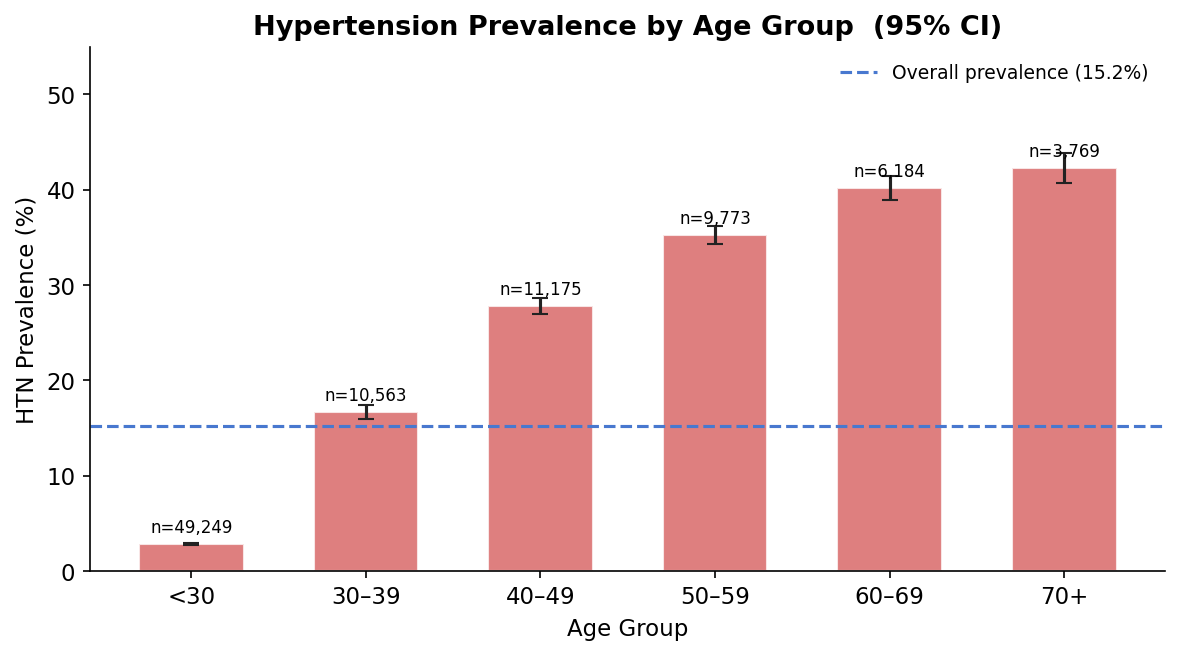

           prevalence      n  prevalence_pct   ci_lo   ci_hi
age_group                                                   
<30            0.0284  49249          2.8386  2.6920  2.9853
30–39          0.1670  10563         16.6998 15.9885 17.4111
40–49          0.2783  11175         27.8300 26.9991 28.6609
50–59          0.3522   9773         35.2195 34.2725 36.1665
60–69          0.4018   6184         40.1843 38.9624 41.4063
70+            0.4229   3769         42.2924 40.7152 43.8696


In [28]:
# ── 11. Hypertension Prevalence by Age Group ─────────────────────────────────
if _age_col:
    _ag = _demo[[_age_col, '__target__']].dropna()
    _ag = _ag[_ag[_age_col] > 0]
    
    bins   = [0, 30, 40, 50, 60, 70, 200]
    labels = ['<30', '30–39', '40–49', '50–59', '60–69', '70+']
    _ag['age_group'] = pd.cut(_ag[_age_col], bins=bins, labels=labels, right=False)
    
    prev = (_ag.groupby('age_group', observed=True)['__target__']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'prevalence', 'count': 'n'}))
    prev['prevalence_pct'] = prev['prevalence'] * 100
    
    # 95% CI (Wilson)
    from scipy.stats import norm as sp_norm
    z = sp_norm.ppf(0.975)
    prev['ci_lo'] = (prev['prevalence'] - z * np.sqrt(prev['prevalence'] * (1 - prev['prevalence']) / prev['n'])) * 100
    prev['ci_hi'] = (prev['prevalence'] + z * np.sqrt(prev['prevalence'] * (1 - prev['prevalence']) / prev['n'])) * 100
    prev['ci_lo'] = prev['ci_lo'].clip(0)
    prev['ci_hi'] = prev['ci_hi'].clip(upper=100)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(prev.index.astype(str), prev['prevalence_pct'],
                  color=PALETTE2[1], alpha=0.8, edgecolor='white', width=0.6)
    ax.errorbar(range(len(prev)), prev['prevalence_pct'],
                yerr=[prev['prevalence_pct'] - prev['ci_lo'],
                      prev['ci_hi'] - prev['prevalence_pct']],
                fmt='none', color='#222', capsize=4, linewidth=1.5)

    for bar, (_, row) in zip(bars, prev.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.2,
                f"n={int(row['n']):,}", ha='center', fontsize=8)
    ax.axhline(y.mean() * 100, color='#4878CF', linestyle='--',
               linewidth=1.5, label=f'Overall prevalence ({y.mean()*100:.1f}%)')
    ax.set_xlabel('Age Group')
    ax.set_ylabel('HTN Prevalence (%)')
    ax.set_title('Hypertension Prevalence by Age Group  (95% CI)', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, min(100, prev['prevalence_pct'].max() * 1.3))
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'fig12_prevalence_by_age_group.png', bbox_inches='tight', dpi=200)
    plt.show()
    print(prev.to_string())
else:
    print("Age column not detected — skipping age group prevalence chart.")

         feature        Q1         Q3  IQR_outliers  IQR_outlier_%  Z>3_outliers  Z>3_%
             fg3    0.0000    25.0920         19682        21.7000          2465 2.7200
            fg21    0.0000     0.0000         17853        19.6800           923 1.0200
            fg12    0.0000     8.0000         17444        19.2300          1133 1.2500
            fg27    0.0000     4.1000         12259        13.5100           587 0.6500
             fg5    0.0000    53.6950         10778        11.8800          1372 1.5100
    anthro_group    3.0000     4.0000          7799         8.6000          2440 2.6900
   psurec_anthro    2.0000     4.0000          6726         7.4100          2534 2.7900
            fg11    0.0000   202.8600          6486         7.1500           672 0.7400
            fg24   56.7000   143.4400          6413         7.0700          1345 1.4800
            fg19    0.0000   226.0000          5994         6.6100          1300 1.4300
            fg17    0.0000   165

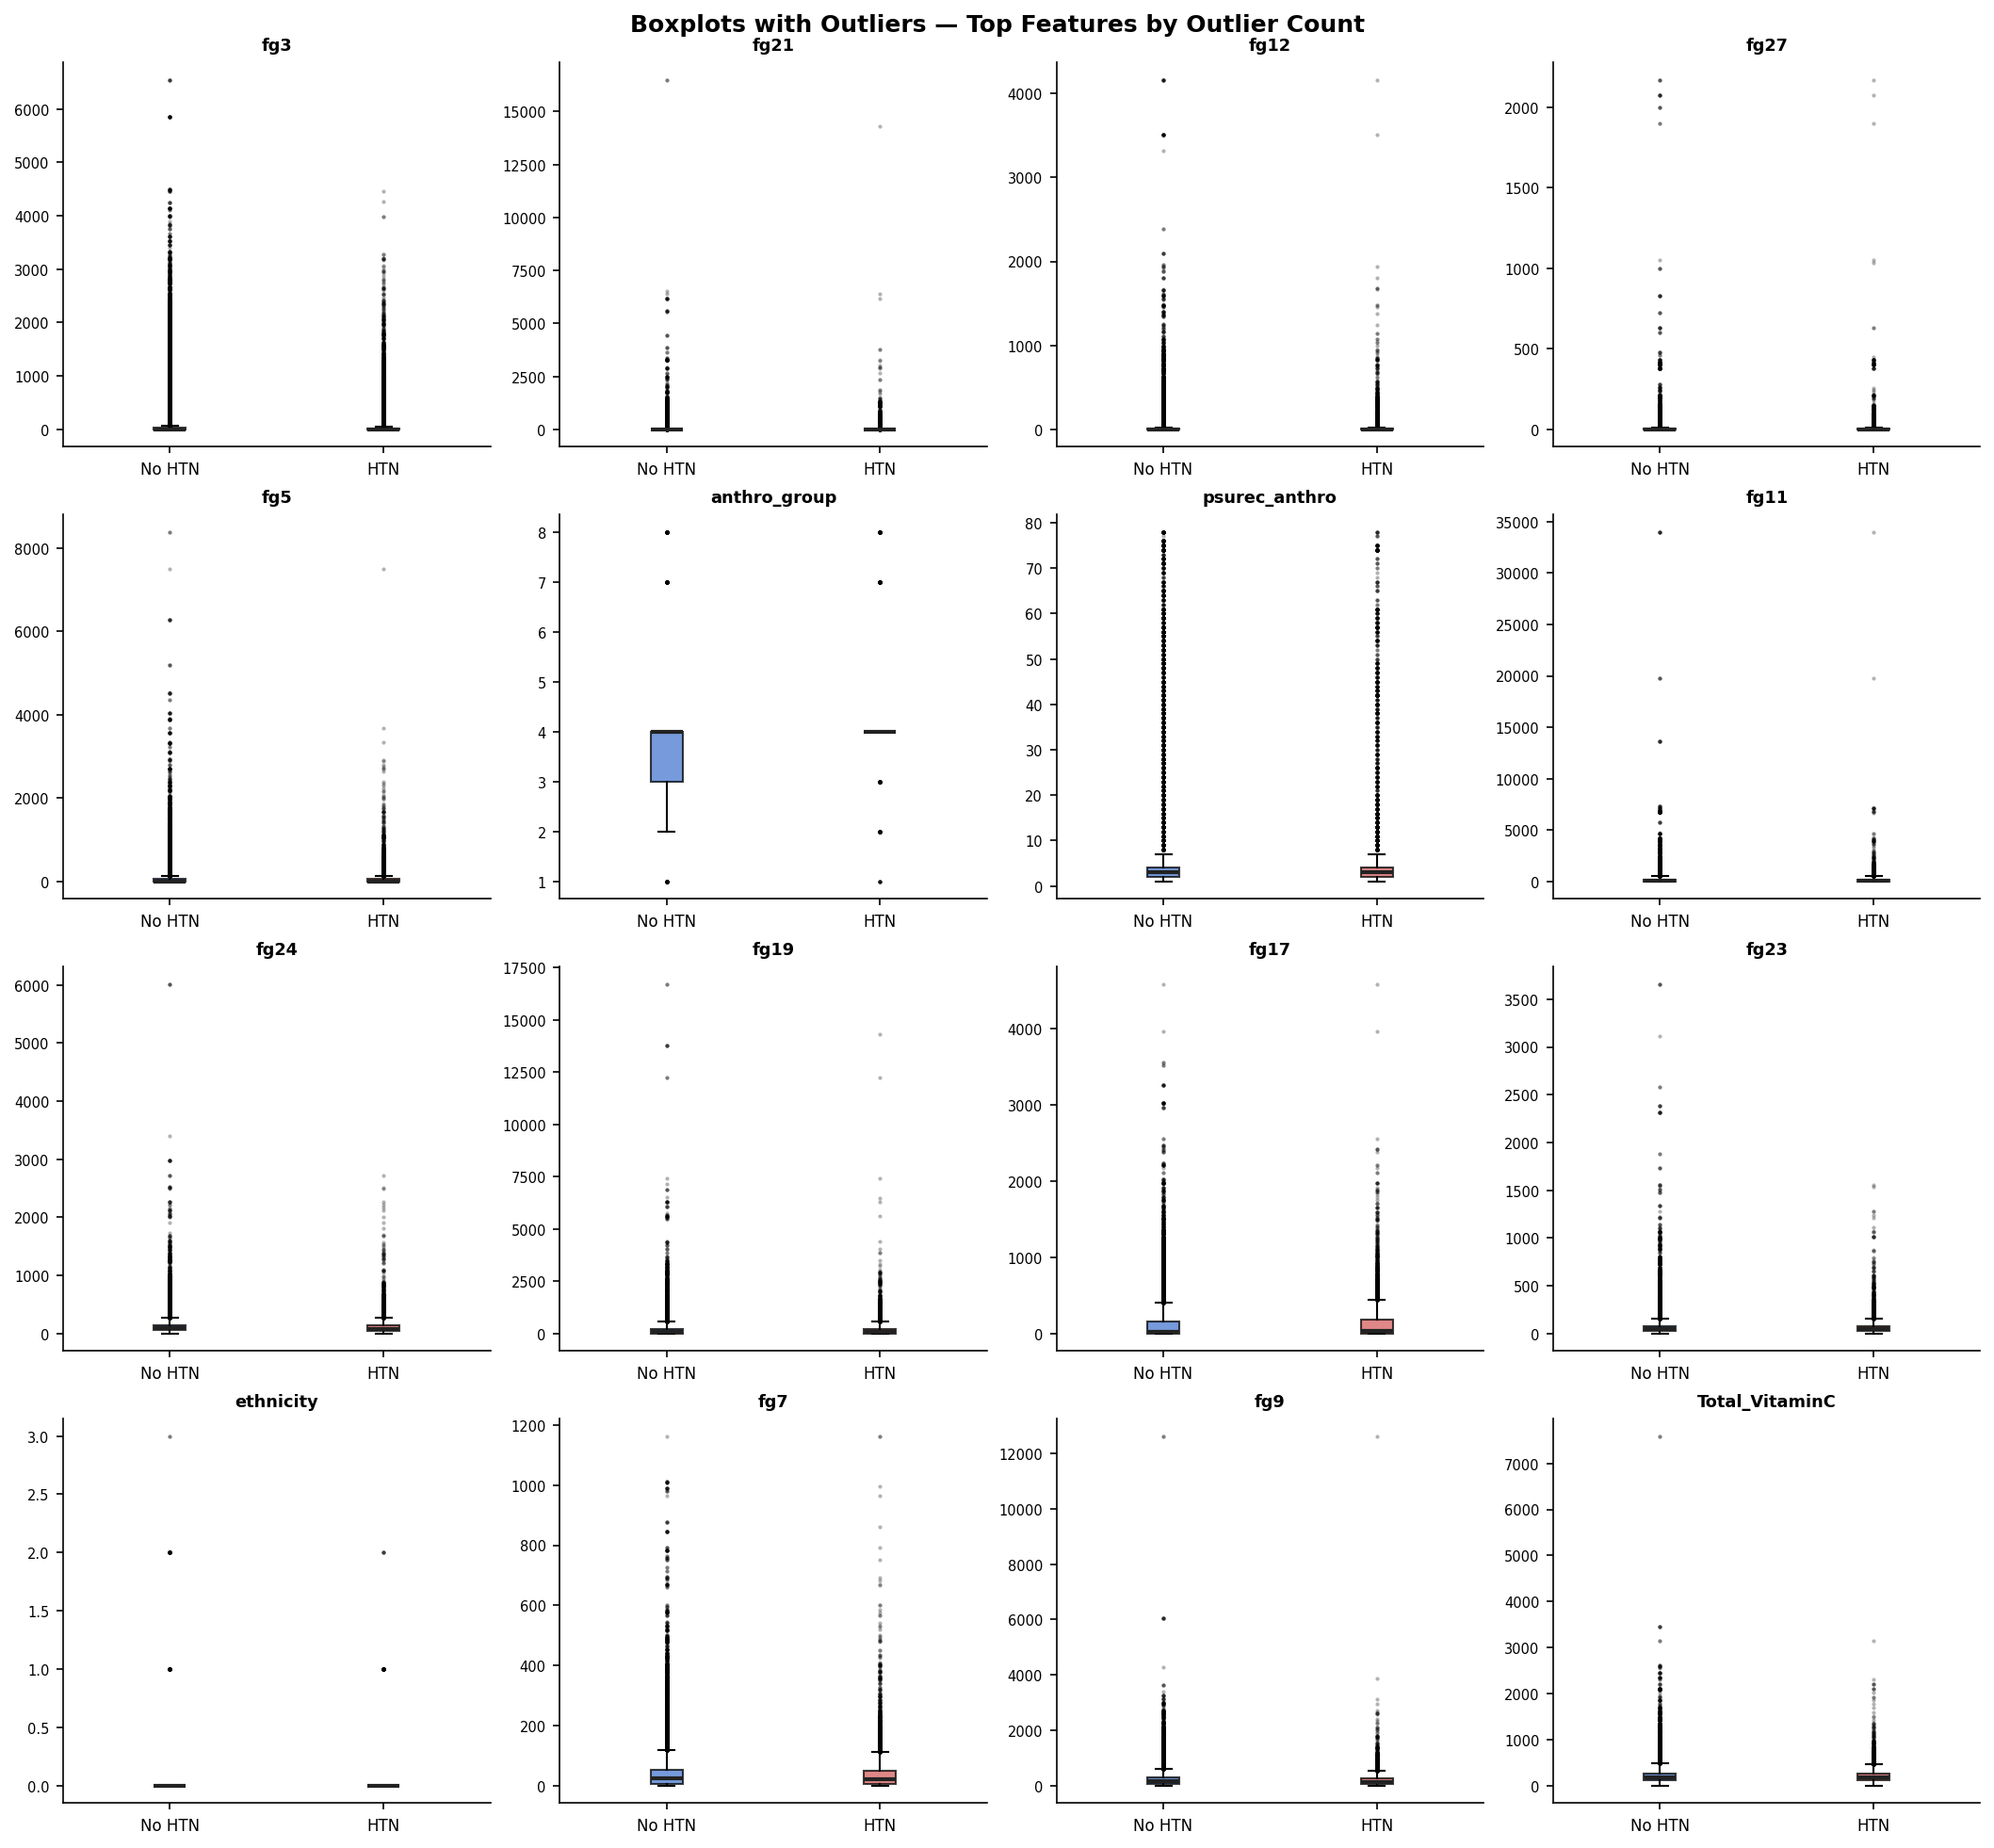

In [29]:
# ── 12. Outlier Summary (IQR method) + Z-score flag ─────────────────────────
outlier_summary = []
for col in e3_num_cols:
    s = _demo[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = int(((s < lo) | (s > hi)).sum())
    z = np.abs(stats.zscore(s))
    n_z  = int((z > 3).sum())
    outlier_summary.append({
        'feature': col, 'Q1': round(Q1, 3), 'Q3': round(Q3, 3),
        'IQR_outliers': n_out, 'IQR_outlier_%': round(n_out/len(s)*100, 2),
        'Z>3_outliers': n_z,   'Z>3_%': round(n_z/len(s)*100, 2),
    })
out_df = pd.DataFrame(outlier_summary).sort_values('IQR_outliers', ascending=False)
print(out_df.to_string(index=False))

# Box-plot matrix for top-outlier features
top_out = out_df[out_df['IQR_outliers'] > 0].head(16)['feature'].tolist()
if top_out:
    ncols = 4
    nrows = int(np.ceil(len(top_out) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3.5, nrows * 3.2),
                             constrained_layout=True)
    axes_flat = np.array(axes).ravel()
    for i, col in enumerate(top_out):
        ax = axes_flat[i]
        grps = [_demo.loc[_demo['__target__'] == cls, col].dropna().values
                for cls in [0, 1]]
        bp = ax.boxplot(grps, patch_artist=True,
                        medianprops=dict(linewidth=2, color='#222'),
                        showfliers=True,
                        flierprops=dict(marker='.', markersize=2, alpha=0.3))
        for j, box in enumerate(bp['boxes']):
            box.set_facecolor(PALETTE2[j])
            box.set_alpha(0.75)
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['No HTN', 'HTN'], fontsize=8)
        ax.set_title(col, fontsize=8.5, fontweight='bold')
        ax.tick_params(axis='y', labelsize=7)
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle('Boxplots with Outliers — Top Features by Outlier Count',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.savefig(PLOT_DIR / 'fig13_boxplots_outliers.png', bbox_inches='tight', dpi=200)
    plt.show()

Dietary / nutrient features found: 5
['Total_Energy', 'Total_Fat', 'Total_Iron', 'Total_Riboflavin', 'Total_VitaminC']


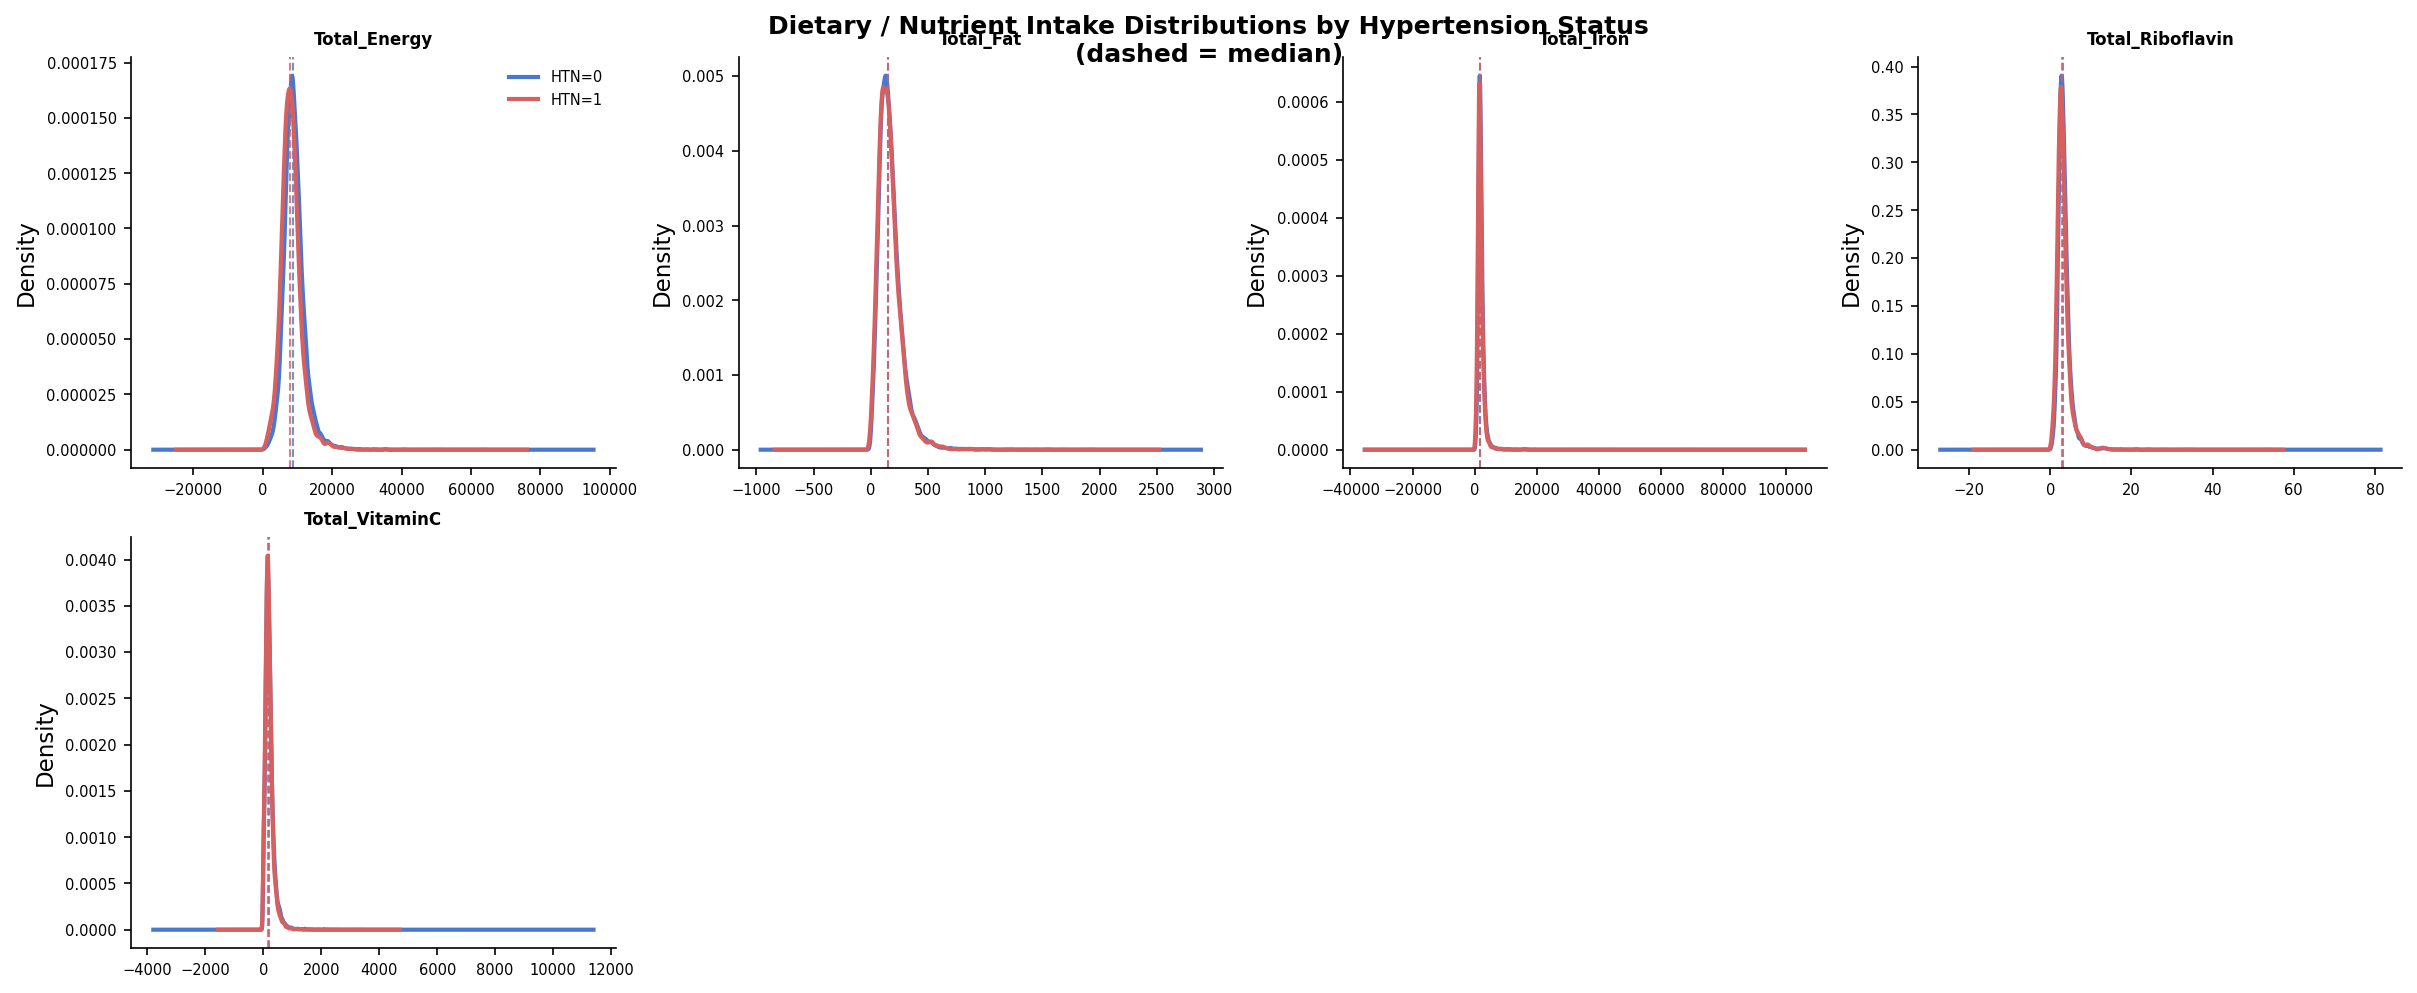


Dietary feature correlations with target:
         feature       r      p  abs_r
    Total_Energy -0.0998 0.0000 0.0998
      Total_Iron -0.0393 0.0000 0.0393
Total_Riboflavin -0.0351 0.0000 0.0351
  Total_VitaminC -0.0288 0.0000 0.0288
       Total_Fat -0.0191 0.0000 0.0191


In [30]:
# ── 13. Dietary Feature Exploration ──────────────────────────────────────────
# Identify likely dietary intake columns (energy, macro-nutrients, micro-nutrients)
dietary_keywords = [
    'energy', 'calorie', 'kcal', 'protein', 'carb', 'fat', 'fibre', 'fiber',
    'sodium', 'potassium', 'calcium', 'iron', 'vitamin', 'vit_', 'sugar',
    'cholesterol', 'saturated', 'pufa', 'mufa', 'omega',
    'diet', 'food', 'intake', 'nutrient', 'retinol', 'folate', 'riboflavin',
    'thiamine', 'niacin', 'ascorbic', 'tocopherol', 'zinc', 'phosphorus',
    'magnesium', 'selenium',
]
dietary_cols = [
    c for c in e3_num_cols
    if any(kw in c.lower() for kw in dietary_keywords)
]

if dietary_cols:
    print(f"Dietary / nutrient features found: {len(dietary_cols)}")
    print(dietary_cols)

    # KDE grids for dietary features
    ncols = 4
    nrows = int(np.ceil(len(dietary_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 4, nrows * 3.2),
                             constrained_layout=True)
    axes_flat = np.array(axes).ravel()
    for i, col in enumerate(dietary_cols):
        ax = axes_flat[i]
        for cls, color in PALETTE.items():
            sub = _demo.loc[_demo['__target__'] == cls, col].dropna()
            if len(sub) > 5:
                sub.plot.kde(ax=ax, color=color, linewidth=2,
                             label=f'HTN={cls}')
                ax.axvline(sub.median(), color=color,
                           linestyle='--', linewidth=1, alpha=0.8)
        ax.set_title(col, fontsize=8, fontweight='bold')
        ax.tick_params(labelsize=7)
        ax.set_xlabel('')
        if i == 0:
            ax.legend(fontsize=7)
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle('Dietary / Nutrient Intake Distributions by Hypertension Status\n'
                 '(dashed = median)',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.savefig(PLOT_DIR / 'fig14_dietary_features.png', bbox_inches='tight', dpi=200)
    plt.show()

    # Nutrient–target associations
    diag_rows = []
    for col in dietary_cols:
        vals = _demo[col].values
        valid = ~np.isnan(vals)
        if valid.sum() < 30:
            continue
        r, p = pointbiserialr(vals[valid], _demo['__target__'].values[valid])
        diag_rows.append({'feature': col, 'r': round(r, 4), 'p': round(p, 5),
                          'abs_r': abs(r)})
    diag_df = pd.DataFrame(diag_rows).sort_values('abs_r', ascending=False)
    print("\nDietary feature correlations with target:")
    print(diag_df.to_string(index=False))
else:
    print("No dietary/nutrient columns detected by keyword matching.")

In [31]:
# ── 14. EDA Summary Table ─────────────────────────────────────────────────────
print("=" * 70)
print("EDA SUMMARY")
print("=" * 70)
print(f"  Dataset              : {data_path.name}")
print(f"  Total samples (N)    : {len(eda_df):,}")
print(f"  Total features       : {eda_df.shape[1]-1}")
print(f"    Numeric (raw)      : {len(num_cols_raw)}")
print(f"    Numeric (post-cull): {len(e3_num_cols)}")
print(f"    Categorical        : {len(cat_cols_raw)}")
print(f"  Target               : {target_col}")
_vc = y.value_counts().sort_index()
print(f"    Class 0 (No HTN)   : {_vc.get(0, 0):,}  ({_vc.get(0,0)/len(y)*100:.1f}%)")
print(f"    Class 1 (HTN)      : {_vc.get(1, 0):,}  ({_vc.get(1,0)/len(y)*100:.1f}%)")
print(f"    Imbalance ratio    : {_vc.max()/_vc.min():.2f}")
miss_pct = (eda_df.drop(columns=['__target__']).isnull().mean() * 100)
print(f"  Missingness (overall): {miss_pct.mean():.2f}% mean  |  max: {miss_pct.max():.2f}% ({miss_pct.idxmax()})")
print(f"  Collinearity filter  : dropped {len(_e3_drop)} features (cutoff={COLLINEARITY_CUTOFF})")
if _e3_drop:
    print(f"    Dropped            : {_e3_drop}")
print()
print("Top-10 features by association with Hypertension:")
print(assoc_df.head(10)[['feature', 'type', 'metric', 'statistic']].to_string(index=False))
print()
print(f"All EDA plots saved to: {PLOT_DIR.resolve()}")

EDA SUMMARY
  Dataset              : merged_clinical_dietary_anthro_leftjoin.csv
  Total samples (N)    : 151,189
  Total features       : 54
    Numeric (raw)      : 54
    Numeric (post-cull): 37
    Categorical        : 0
  Target               : Hypertension
    Class 0 (No HTN)   : 128,201  (84.8%)
    Class 1 (HTN)      : 22,988  (15.2%)
    Imbalance ratio    : 5.58
  Missingness (overall): 61.02% mean  |  max: 99.01% (mos_preg)
  Collinearity filter  : dropped 17 features (cutoff=0.7)
    Dropped            : ['Total_Calcium', 'Total_CHO', 'Total_FoodIntake', 'Total_Niacin', 'Total_Protein', 'Total_Thiamin', 'Total_VitaminA', 'fg1', 'fg10', 'fg13', 'fg14', 'fg16', 'fg2', 'fg20', 'fg25', 'regcode_anthro', 'psc_anthro']

Top-10 features by association with Hypertension:
         feature    type           metric  statistic
             age numeric Point-biserial r     0.4138
             bmi numeric Point-biserial r     0.3344
             whr numeric Point-biserial r     0.2681
 